In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder
from scipy.stats import binomtest
import os
import glob
import h5py
from temporaldata import Data

from auditorydecoding.windowing import extract_windows
from auditorydecoding.plotting import plot_signal, plot_pca_variance, plot_covariance, plot_spectrum
from scipy.signal import butter, sosfilt
from einops import rearrange

/capstor/scratch/cscs/awgolab/mila_test/auditorydecoding/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-11 11:03:15,344	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## Configuration

In [4]:
WINDOW_LENGTH = 0.5  # seconds
FOLD_NUM = 0
SPLIT_TYPE = "intrasession-causal"
TASK_TYPE = "acoustic_stim"

DATA_ROOT = "/capstor/store/cscs/swissai/a0091/processed/neurosoft_monkeys_2026"

# Discover all recordings automatically
ALL_RECORDING_PATHS = sorted(glob.glob(os.path.join(DATA_ROOT, "*.h5")))
print(f"Found {len(ALL_RECORDING_PATHS)} recordings:")
for p in ALL_RECORDING_PATHS:
    print(" ", os.path.basename(p))

Found 27 recordings:
  sub-01_ses-010_task-AcousStim_acq-RH_desc-raw.h5
  sub-01_ses-011_task-AcousStim_acq-RH_desc-raw.h5
  sub-01_ses-012_task-AcousStim_acq-RH_desc-raw.h5
  sub-01_ses-013_task-AcousStim_acq-RH_desc-raw.h5
  sub-01_ses-014_task-AcousStim_acq-RH_desc-raw.h5
  sub-01_ses-015_task-AcousStim_acq-RH_desc-raw.h5
  sub-01_ses-016_task-AcousStim_acq-RH_desc-raw.h5
  sub-01_ses-01_task-AcousStim_acq-RH_desc-raw.h5
  sub-01_ses-02_task-AcousStim_acq-RH_desc-raw.h5
  sub-01_ses-03_task-AcousStim_acq-RH_desc-raw.h5
  sub-01_ses-04_task-AcousStim_acq-RH_desc-raw.h5
  sub-01_ses-05_task-AcousStim_acq-RH_desc-raw.h5
  sub-01_ses-06_task-AcousStim_acq-RH_desc-raw.h5
  sub-01_ses-07_task-AcousStim_acq-RH_desc-raw.h5
  sub-01_ses-08_task-AcousStim_acq-RH_desc-raw.h5
  sub-01_ses-09_task-AcousStim_acq-RH_desc-raw.h5
  sub-02_ses-01_task-AcousStim_acq-RH_desc-raw.h5
  sub-02_ses-02_task-AcousStim_acq-RH_desc-raw.h5
  sub-02_ses-03_task-AcousStim_acq-RH_desc-raw.h5
  sub-02_ses-04_task-A

## Helper functions

In [19]:
from scipy.signal import welch, iirnotch, filtfilt

def plot_spectrum2(signal, fs, lowcut=29, highcut=70, title=""):
    f, psd = welch(signal.flatten(), fs, nperseg=1023)
    plt.figure(figsize=(4, 3))
    plt.semilogy(f, psd, label="Signal", alpha=.7)
    plt.axvline(lowcut, color="k", linestyle="--", alpha=.7, label="Cutoffs")
    plt.axvline(highcut, color="k", linestyle="--", alpha=.7)
    plt.title(f"PSD{' – ' + title if title else ''}")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("PSD [V**1/Hz]")
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=.7)
    plt.show()


def bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    sos = butter(order, [low, high], analog=False, btype="band", output="sos")
    return sosfilt(sos, data, axis=0)


def notch_filter(data, fs, notch_frequency, quality_factor=30, harmonics=1):
    nyquist = 0.5 * fs
    target_frequencies = [
        notch_frequency * harmonic
        for harmonic in range(1, harmonics + 1)
        if notch_frequency * harmonic < nyquist
    ]
    filtered = np.asarray(data)
    for target_frequency in target_frequencies:
        b, a = iirnotch(target_frequency, quality_factor, fs=fs)
        filtered = filtfilt(b, a, filtered, axis=0)
    return filtered


def apply_preprocessing(data, fs, lowcut, highcut,
                         filter_signal=False, bandpass_order=6,
                         apply_notch=False, notch_freq=50.0,
                         notch_q=30, notch_harmonics=3):
    processed = data
    if filter_signal:
        processed = bandpass_filter(processed, lowcut, highcut, fs, order=bandpass_order)
    if apply_notch:
        processed = notch_filter(processed, fs, notch_frequency=notch_freq,
                                 quality_factor=notch_q, harmonics=notch_harmonics)
    return processed


def run_decoding_for_recording(path, cfg):
    """
    Full decoding pipeline for a single recording.
    Returns a dict with recording id, validation accuracy, balanced accuracy,
    p-values, and classification report.
    """
    recording_id = os.path.splitext(os.path.basename(path))[0]
    print(f"\n{'='*60}")
    print(f"Recording: {recording_id}")
    print(f"{'='*60}")

    with h5py.File(path) as f:
        data = Data.from_hdf5(f, lazy=False)

    keep_channels = data.channels.type == "ecog"
    channel_names = data.channels.id[keep_channels]
    signal = data.ecog.signal[:, keep_channels]
    timestamps = data.ecog.timestamps

    train_intervals = data.splits.acoustic_stim_causal_train.coalesce()
    data_train = np.concatenate([
        data.slice(iv[0], iv[1]).ecog.signal[:, keep_channels]
        for iv in train_intervals
    ], axis=0)

    fs = cfg["fs"]
    filtered_signal = apply_preprocessing(
        signal, fs,
        cfg["lowcut"], cfg["highcut"],
        filter_signal=cfg["FILTER_SIGNAL"],
        bandpass_order=cfg["BANDPASS_ORDER"],
        apply_notch=cfg["APPLY_NOTCH_FILTER"],
        notch_freq=cfg["NOTCH_FREQUENCY"],
        notch_q=cfg["NOTCH_Q"],
        notch_harmonics=cfg["NOTCH_HARMONICS"],
    )
    data_train_proc = apply_preprocessing(
        data_train, fs,
        cfg["lowcut"], cfg["highcut"],
        filter_signal=cfg["FILTER_SIGNAL"],
        bandpass_order=cfg["BANDPASS_ORDER"],
        apply_notch=cfg["APPLY_NOTCH_FILTER"],
        notch_freq=cfg["NOTCH_FREQUENCY"],
        notch_q=cfg["NOTCH_Q"],
        notch_harmonics=cfg["NOTCH_HARMONICS"],
    )

    if cfg["ZSCORE_BEFORE_PCA"]:
        data_train_proc = (
            (data_train_proc - data_train_proc.mean(axis=0))
            / data_train_proc.std(axis=0)
        )

    pca = PCA(whiten=cfg["WHITENING"], n_components=cfg["N_COMPONENTS"]).fit(data_train_proc)

    if cfg["APPLY_WHITENING"]:
        signal_whitened = pca.transform(filtered_signal)
    else:
        signal_whitened = filtered_signal

    if cfg["NORM_BY_CHANNEL"]:
        train_transformed = pca.transform(data_train_proc)
        signal_whitened = (
            (signal_whitened - train_transformed.mean(axis=0))
            / train_transformed.std(axis=0)
        )

    X_windows_train, y_windows_train = extract_windows(signal_whitened, timestamps, data.splits.acoustic_stim_causal_train, cfg["WINDOW_LENGTH"])
    X_windows_valid, y_windows_valid = extract_windows(signal_whitened, timestamps, data.splits.acoustic_stim_causal_valid, cfg["WINDOW_LENGTH"])

    le = LabelEncoder().fit(y_windows_train)
    y_train_enc = le.transform(y_windows_train)
    y_valid_enc = le.transform(y_windows_valid)

    print(f"  train: X={X_windows_train.shape}  y={y_windows_train.shape}")
    print(f"  valid: X={X_windows_valid.shape}  y={y_windows_valid.shape}")

    X_train = X_windows_train
    X_valid = X_windows_valid

    fs_effective = fs
    BIN_SIZE = cfg["BIN_SIZE"]
    if BIN_SIZE > 1:
        n_samples = X_train.shape[1]
        if cfg["RESAMPLE_METHOD"] == "bin":
            n_bins = n_samples // BIN_SIZE
            X_train = X_train[:, :n_bins * BIN_SIZE, :].reshape(
                X_train.shape[0], n_bins, BIN_SIZE, -1).mean(axis=2)
            X_valid = X_valid[:, :n_bins * BIN_SIZE, :].reshape(
                X_valid.shape[0], n_bins, BIN_SIZE, -1).mean(axis=2)
        elif cfg["RESAMPLE_METHOD"] == "decimate":
            from scipy.signal import decimate
            X_train = np.stack([
                decimate(X_train[:, :, i], BIN_SIZE, axis=1)
                for i in range(X_train.shape[2])
            ], axis=2)
            X_valid = np.stack([
                decimate(X_valid[:, :, i], BIN_SIZE, axis=1)
                for i in range(X_valid.shape[2])
            ], axis=2)
        fs_effective = fs / BIN_SIZE

    if cfg["STFT"]:
        n_time = X_train.shape[1]
        X_train = np.log(np.abs(np.fft.rfft(X_train, axis=1)).clip(min=1e-10))
        X_valid = np.log(np.abs(np.fft.rfft(X_valid, axis=1)).clip(min=1e-10))
        freqs = np.fft.rfftfreq(n_time, d=1 / fs_effective)

        if cfg["CROP_FREQS"]:
            valid_indices = (freqs >= cfg["lowcut"]) & (freqs <= cfg["highcut"])
            X_train = X_train[:, valid_indices, :]
            X_valid = X_valid[:, valid_indices, :]

    if cfg["ZSCORE_FEATURES"]:
        X_train_mean = X_train.mean(axis=0)
        X_train_std = X_train.std(axis=0)
        X_train = (X_train - X_train_mean) / (X_train_std + 1e-8)
        X_valid = (X_valid - X_train_mean) / (X_train_std + 1e-8)

    if cfg["STD"]:
        X_train = (X_train - X_train.mean(axis=1, keepdims=True)) / (
            X_train.std(axis=1, keepdims=True) + 1e-8)
        X_valid = (X_valid - X_valid.mean(axis=1, keepdims=True)) / (
            X_valid.std(axis=1, keepdims=True) + 1e-8)

    if cfg["FLATTEN"]:
        X_train = rearrange(X_train, "s t c -> s (c t)")
        X_valid = rearrange(X_valid, "s t c -> s (c t)")

    print(f"  Feature shapes: train {X_train.shape}  valid {X_valid.shape}")

    clf = LogisticRegression(max_iter=10_000)
    clf.fit(X_train, y_train_enc)
    y_pred_valid = clf.predict(X_valid)

    val_acc = accuracy_score(y_valid_enc, y_pred_valid)
    val_bal_acc = balanced_accuracy_score(y_valid_enc, y_pred_valid)

    print(f"  Validation accuracy: {val_acc:.3f}")
    print(f"  Balanced accuracy:   {val_bal_acc:.3f}")
    print()
    print(classification_report(y_valid_enc, y_pred_valid, target_names=le.classes_))

    n_classes = len(le.classes_)
    _, counts = np.unique(y_valid_enc, return_counts=True)
    majority_chance = counts.max() / counts.sum()
    n_correct = (y_pred_valid == y_valid_enc).sum()
    n_total = len(y_valid_enc)

    binom_result = binomtest(n_correct, n_total, p=majority_chance, alternative="greater")

    rng = np.random.default_rng(0)
    N_PERMUTATIONS = cfg["N_PERMUTATIONS"]
    null_bal_accs = np.array([
        balanced_accuracy_score(rng.permutation(y_valid_enc), y_pred_valid)
        for _ in range(N_PERMUTATIONS)
    ])
    permutation_pvalue = (null_bal_accs >= val_bal_acc).mean()

    print(f"  Binomial p-value   : {binom_result.pvalue:.4g}  (H0: acc ≤ {majority_chance:.3f})")
    print(f"  Permutation p-value: {permutation_pvalue:.4g}")

    uniform_chance = 1.0 / n_classes
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion matrix
    cm = confusion_matrix(y_valid_enc, y_pred_valid)
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm, annot=True, fmt=".2f", xticklabels=le.classes_, yticklabels=le.classes_,
                ax=axes[0], cmap="Blues")
    axes[0].set_title(f"Confusion matrix – {recording_id}\nval acc={val_acc:.3f}")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    # Permutation test
    axes[1].hist(null_bal_accs, bins=50, color="steelblue", alpha=0.7, label="Null")
    axes[1].axvline(val_bal_acc, color="crimson", linewidth=2,
                    label=f"Observed ({val_bal_acc:.3f})")
    axes[1].axvline(uniform_chance, color="gray", linewidth=1.5, linestyle="--",
                    label=f"Chance (1/{n_classes}={uniform_chance:.3f})")
    axes[1].set_xlabel("Balanced accuracy")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"Permutation test – {recording_id}\n(p={permutation_pvalue:.4g})")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {
        "recording_id": recording_id,
        "n_channels": int(keep_channels.sum()),
        "n_train": X_train.shape[0],
        "n_valid": X_valid.shape[0],
        "n_classes": n_classes,
        "classes": list(le.classes_),
        "val_acc": val_acc,
        "val_bal_acc": val_bal_acc,
        "majority_chance": majority_chance,
        "uniform_chance": uniform_chance,
        "binom_pvalue": binom_result.pvalue,
        "permutation_pvalue": permutation_pvalue,
        "X_train": X_train,
        "X_valid": X_valid,
        "y_train_enc": y_train_enc,
        "y_valid_enc": y_valid_enc,
        "y_pred_valid": y_pred_valid,
        "le": le,
    }

## Processing parameters
Edit these to change preprocessing / feature extraction behaviour.

In [10]:
CFG = dict(
    WINDOW_LENGTH = 0.5,       # seconds

    # ── Sampling / filtering ──────────────────────────────────────
    fs            = 2000,
    lowcut        = 0.5,
    highcut       = 300,
    FILTER_SIGNAL = False,
    BANDPASS_ORDER = 6,
    APPLY_NOTCH_FILTER = False,
    NOTCH_FREQUENCY = 50.0,
    NOTCH_Q = 30,
    NOTCH_HARMONICS = 3,

    # ── PCA / whitening ───────────────────────────────────────────
    ZSCORE_BEFORE_PCA = False,
    WHITENING = True,
    N_COMPONENTS = None,
    APPLY_WHITENING = True,
    NORM_BY_CHANNEL = False,

    # ── Feature engineering ───────────────────────────────────────
    BIN_SIZE = 1,
    RESAMPLE_METHOD = "decimate",  # "bin" or "decimate"
    STFT = True,
    CROP_FREQS = False,
    ZSCORE_FEATURES = False,
    STD = False,
    FLATTEN = True,

    # ── Statistics ────────────────────────────────────────────────
    N_PERMUTATIONS = 10000,
)

## Run decoding for all monkeys


Recording: sub-01_ses-010_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1262/1262 [00:12<00:00, 101.54it/s]
Skipping 1.0000 seconds of data due to short intervals. Remaining: 630.0 seconds.
Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 205/205 [00:02<00:00, 101.40it/s]


  train: X=(1260, 1000, 29)  y=(1260,)
  valid: X=(205, 1000, 29)  y=(205,)
  Feature shapes: train (1260, 14529)  valid (205, 14529)
  Validation accuracy: 0.439
  Balanced accuracy:   0.372

              precision    recall  f1-score   support

stim_20000Hz       0.35      0.30      0.32        27
 stim_2000Hz       0.00      0.00      0.00        11
  stim_200Hz       0.50      0.40      0.44        25
 stim_4000Hz       0.45      0.40      0.43        25
 stim_5000Hz       0.28      0.32      0.30        44
  stim_800Hz       0.53      0.69      0.60        61
     stim_wn       0.86      0.50      0.63        12

    accuracy                           0.44       205
   macro avg       0.42      0.37      0.39       205
weighted avg       0.43      0.44      0.43       205

  Binomial p-value   : 1.262e-05  (H0: acc ≤ 0.298)
  Permutation p-value: 0


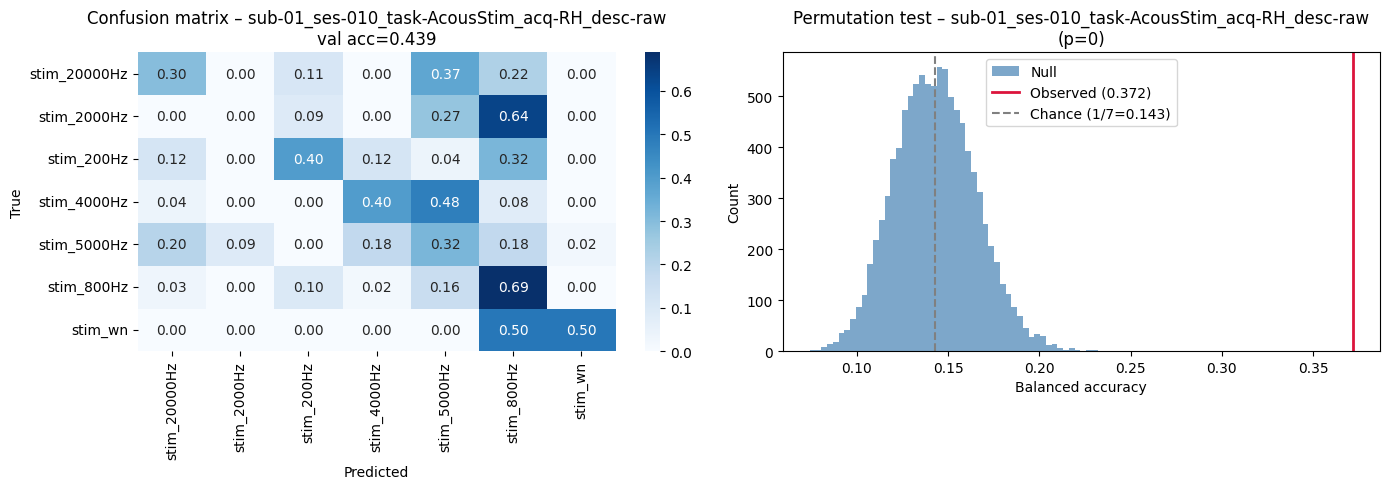


Recording: sub-01_ses-011_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:04<00:00, 70.77it/s]


  train: X=(1823, 1000, 29)  y=(1823,)
  valid: X=(296, 1000, 29)  y=(296,)
  Feature shapes: train (1823, 14529)  valid (296, 14529)
  Validation accuracy: 0.260
  Balanced accuracy:   0.230

              precision    recall  f1-score   support

stim_10000Hz       0.09      0.08      0.08        13
 stim_1000Hz       0.16      0.19      0.17        27
stim_12000Hz       0.33      0.07      0.11        15
stim_16000Hz       0.32      0.25      0.28        32
stim_20000Hz       0.12      0.11      0.12        27
 stim_2000Hz       0.42      0.67      0.51        27
  stim_200Hz       0.35      0.23      0.28        26
 stim_4000Hz       0.16      0.19      0.18        26
 stim_5000Hz       0.34      0.44      0.39        27
  stim_500Hz       0.12      0.19      0.15        26
 stim_8000Hz       0.39      0.50      0.44        24
  stim_800Hz       0.00      0.00      0.00        12
     stim_wn       0.50      0.07      0.12        14

    accuracy                           0.26      

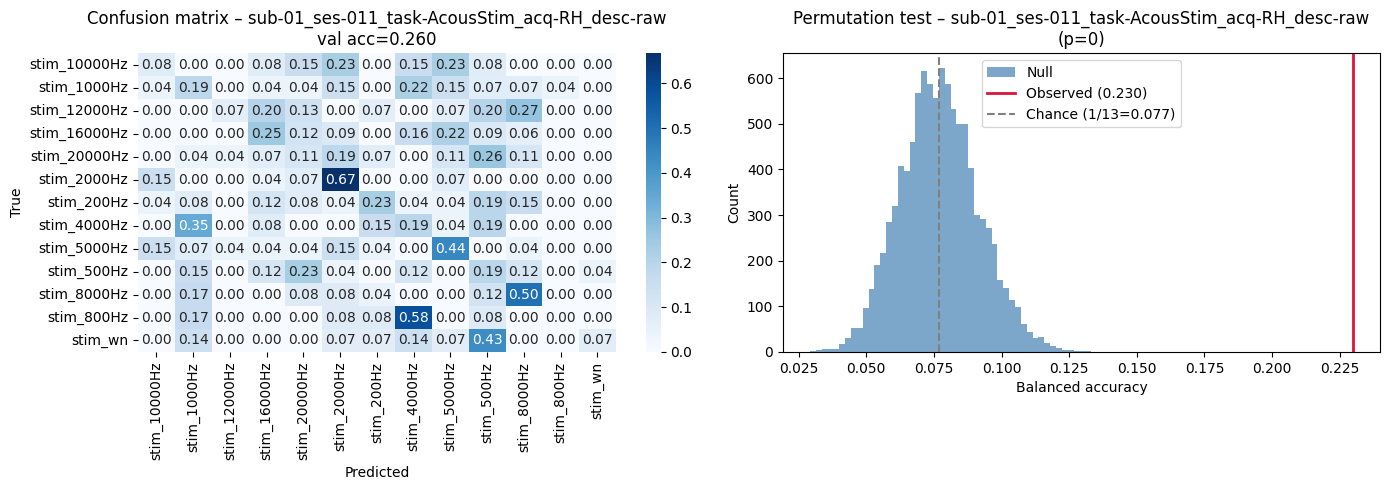


Recording: sub-01_ses-012_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 56/56 [00:00<00:00, 360.11it/s]


  train: X=(352, 1000, 29)  y=(352,)
  valid: X=(56, 1000, 29)  y=(56,)
  Feature shapes: train (352, 14529)  valid (56, 14529)
  Validation accuracy: 0.357
  Balanced accuracy:   0.358

              precision    recall  f1-score   support

stim_10000Hz       0.37      0.64      0.47        11
 stim_1000Hz       0.40      0.18      0.25        11
stim_20000Hz       0.36      0.36      0.36        11
 stim_5000Hz       0.67      0.33      0.44        12
  stim_800Hz       0.20      0.27      0.23        11

    accuracy                           0.36        56
   macro avg       0.40      0.36      0.35        56
weighted avg       0.40      0.36      0.35        56

  Binomial p-value   : 0.009989  (H0: acc ≤ 0.214)
  Permutation p-value: 0.0033


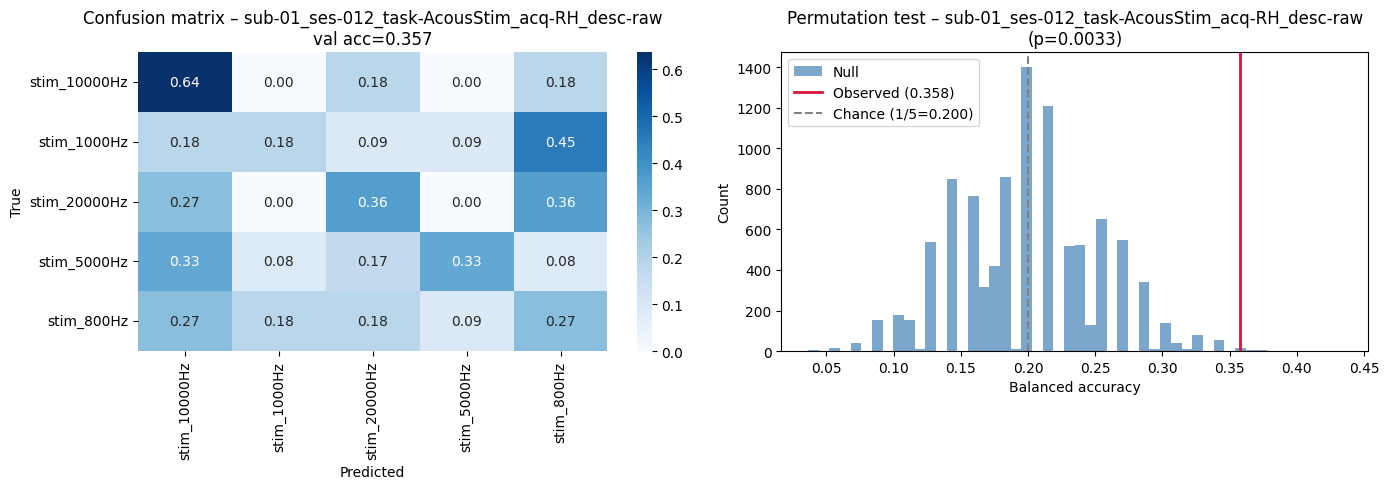


Recording: sub-01_ses-013_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 205.52it/s]


  train: X=(621, 1000, 29)  y=(621,)
  valid: X=(100, 1000, 29)  y=(100,)
  Feature shapes: train (621, 14529)  valid (100, 14529)
  Validation accuracy: 0.210
  Balanced accuracy:   0.210

              precision    recall  f1-score   support

stim_10000Hz       0.09      0.10      0.10        10
 stim_1000Hz       0.08      0.09      0.09        11
stim_12000Hz       0.00      0.00      0.00        11
stim_20000Hz       0.30      0.27      0.29        11
 stim_2000Hz       0.43      0.55      0.48        11
 stim_5000Hz       0.24      0.33      0.28        12
  stim_500Hz       0.00      0.00      0.00        12
 stim_8000Hz       0.29      0.18      0.22        11
  stim_800Hz       0.67      0.36      0.47        11

    accuracy                           0.21       100
   macro avg       0.23      0.21      0.21       100
weighted avg       0.23      0.21      0.21       100

  Binomial p-value   : 0.007269  (H0: acc ≤ 0.120)
  Permutation p-value: 0.0022


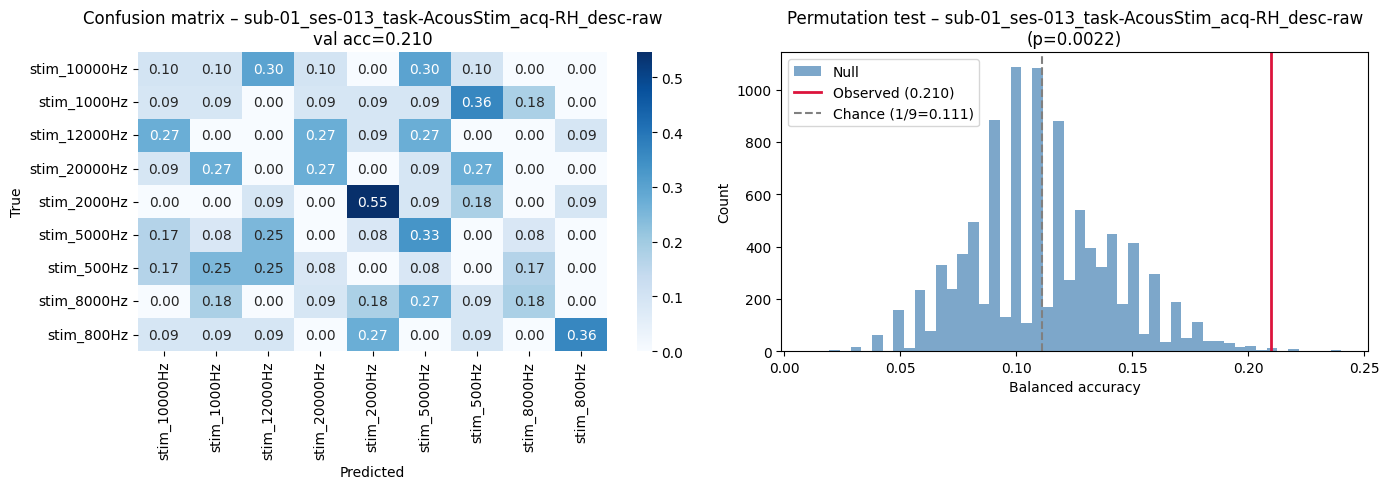


Recording: sub-01_ses-014_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 947/947 [00:06<00:00, 139.45it/s]
Skipping 2.0000 seconds of data due to short intervals. Remaining: 471.5 seconds.
Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 154/154 [00:01<00:00, 138.88it/s]


  train: X=(943, 1000, 29)  y=(943,)
  valid: X=(154, 1000, 29)  y=(154,)
  Feature shapes: train (943, 14529)  valid (154, 14529)
  Validation accuracy: 0.318
  Balanced accuracy:   0.220

              precision    recall  f1-score   support

stim_10000Hz       0.50      0.23      0.32        13
 stim_1000Hz       0.32      0.69      0.44        32
stim_16000Hz       0.00      0.00      0.00        12
stim_20000Hz       0.32      0.58      0.41        24
 stim_2000Hz       0.00      0.00      0.00        12
 stim_3000Hz       0.00      0.00      0.00        11
 stim_5000Hz       0.67      0.17      0.27        12
 stim_8000Hz       0.00      0.00      0.00        12
  stim_800Hz       0.32      0.31      0.31        26

    accuracy                           0.32       154
   macro avg       0.24      0.22      0.19       154
weighted avg       0.26      0.32      0.26       154



/capstor/scratch/cscs/awgolab/mila_test/auditorydecoding/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/capstor/scratch/cscs/awgolab/mila_test/auditorydecoding/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/capstor/scratch/cscs/awgolab/mila_test/auditorydecoding/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

  Binomial p-value   : 0.0008822  (H0: acc ≤ 0.208)
  Permutation p-value: 0


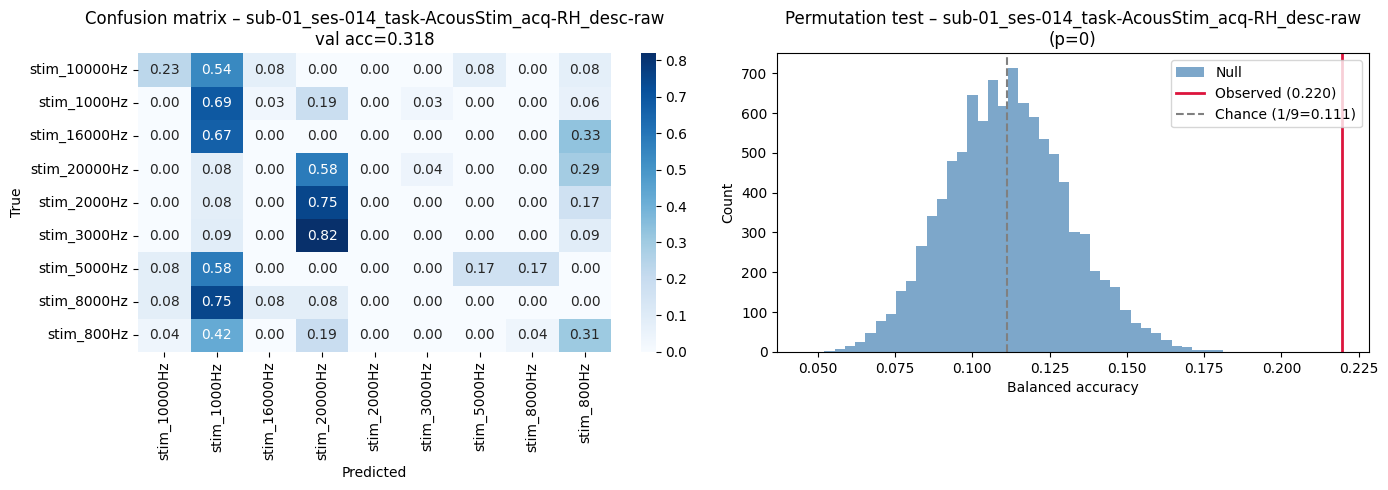


Recording: sub-01_ses-015_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 716/716 [00:03<00:00, 184.10it/s]
Skipping 1.5000 seconds of data due to short intervals. Remaining: 356.5 seconds.
Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 116/116 [00:00<00:00, 182.76it/s]


  train: X=(713, 1000, 29)  y=(713,)
  valid: X=(116, 1000, 29)  y=(116,)
  Feature shapes: train (713, 14529)  valid (116, 14529)
  Validation accuracy: 0.371
  Balanced accuracy:   0.236

              precision    recall  f1-score   support

stim_10000Hz       0.00      0.00      0.00        11
 stim_1000Hz       0.17      0.08      0.11        12
stim_13000Hz       0.33      0.08      0.13        12
stim_18000Hz       1.00      0.91      0.95        11
 stim_5000Hz       0.14      0.08      0.11        12
  stim_650Hz       0.00      0.00      0.00         3
 stim_7700Hz       0.00      0.00      0.00        12
  stim_800Hz       0.00      0.00      0.00        12
 stim_9500Hz       0.36      0.97      0.53        31

    accuracy                           0.37       116
   macro avg       0.22      0.24      0.20       116
weighted avg       0.26      0.37      0.27       116



/capstor/scratch/cscs/awgolab/mila_test/auditorydecoding/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/capstor/scratch/cscs/awgolab/mila_test/auditorydecoding/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/capstor/scratch/cscs/awgolab/mila_test/auditorydecoding/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

  Binomial p-value   : 0.009419  (H0: acc ≤ 0.267)
  Permutation p-value: 0


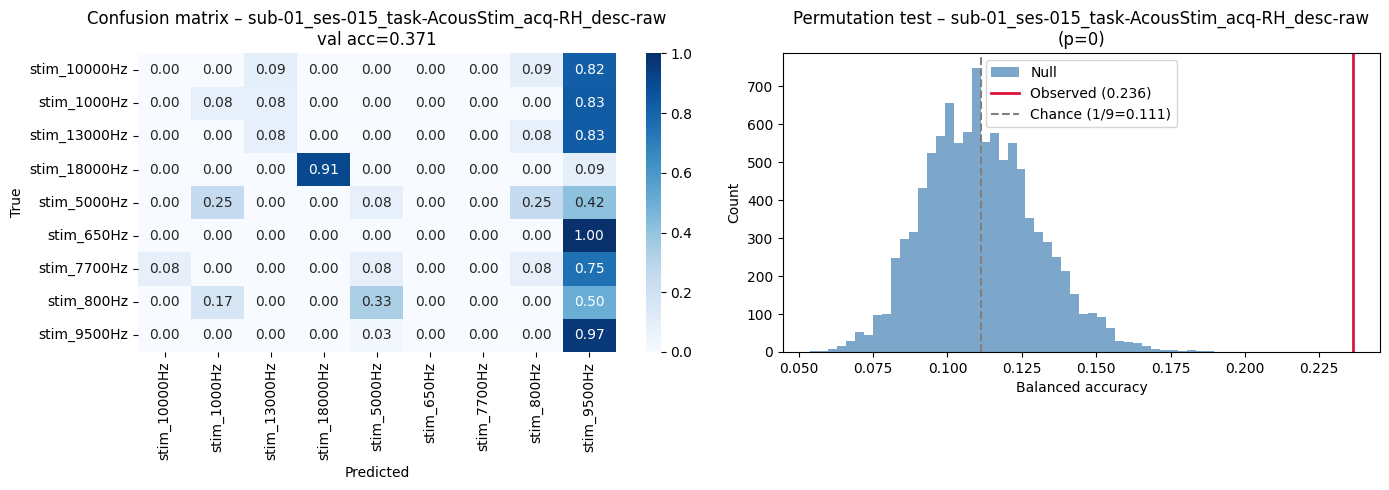


Recording: sub-01_ses-016_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 23/23 [00:00<00:00, 880.30it/s]


  train: X=(143, 1000, 29)  y=(143,)
  valid: X=(23, 1000, 29)  y=(23,)
  Feature shapes: train (143, 14529)  valid (23, 14529)
  Validation accuracy: 0.652
  Balanced accuracy:   0.655

              precision    recall  f1-score   support

 stim_5000Hz       0.70      0.58      0.64        12
  stim_800Hz       0.62      0.73      0.67        11

    accuracy                           0.65        23
   macro avg       0.66      0.66      0.65        23
weighted avg       0.66      0.65      0.65        23

  Binomial p-value   : 0.1483  (H0: acc ≤ 0.522)
  Permutation p-value: 0.14


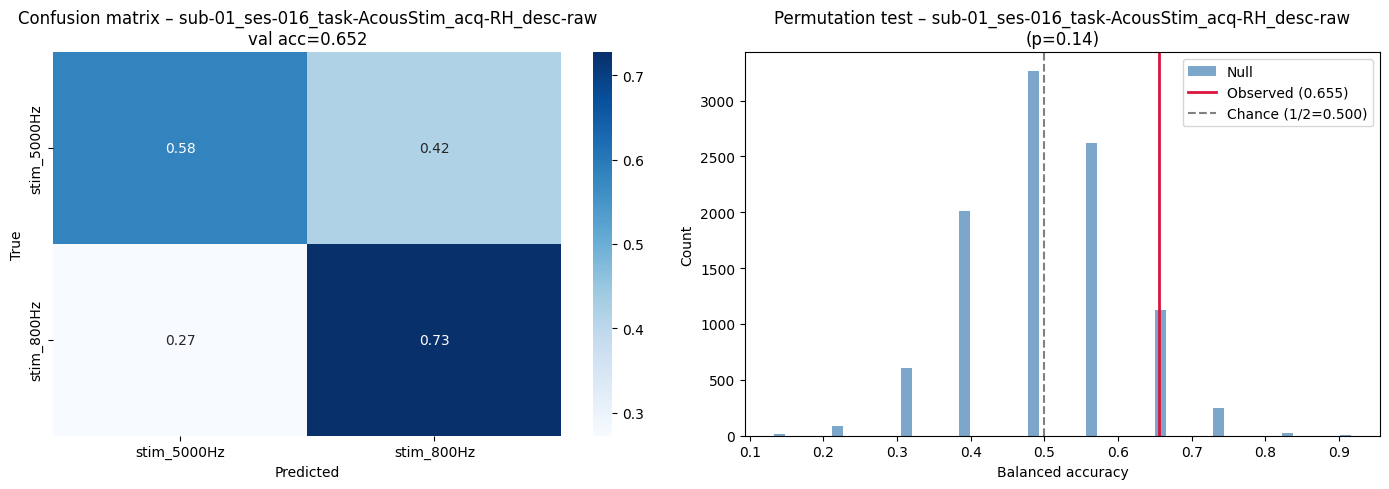


Recording: sub-01_ses-01_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 335/335 [00:00<00:00, 391.71it/s]
Skipping 1.5000 seconds of data due to short intervals. Remaining: 166.0 seconds.
Extracting windows: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 383.17it/s]


  train: X=(332, 1000, 29)  y=(332,)
  valid: X=(53, 1000, 29)  y=(53,)
  Feature shapes: train (332, 14529)  valid (53, 14529)
  Validation accuracy: 0.679
  Balanced accuracy:   0.655

              precision    recall  f1-score   support

 stim_1000Hz       0.91      0.91      0.91        22
 stim_8000Hz       0.47      0.58      0.52        12
  stim_800Hz       0.56      0.47      0.51        19

    accuracy                           0.68        53
   macro avg       0.65      0.66      0.65        53
weighted avg       0.68      0.68      0.68        53

  Binomial p-value   : 9.268e-05  (H0: acc ≤ 0.415)
  Permutation p-value: 0


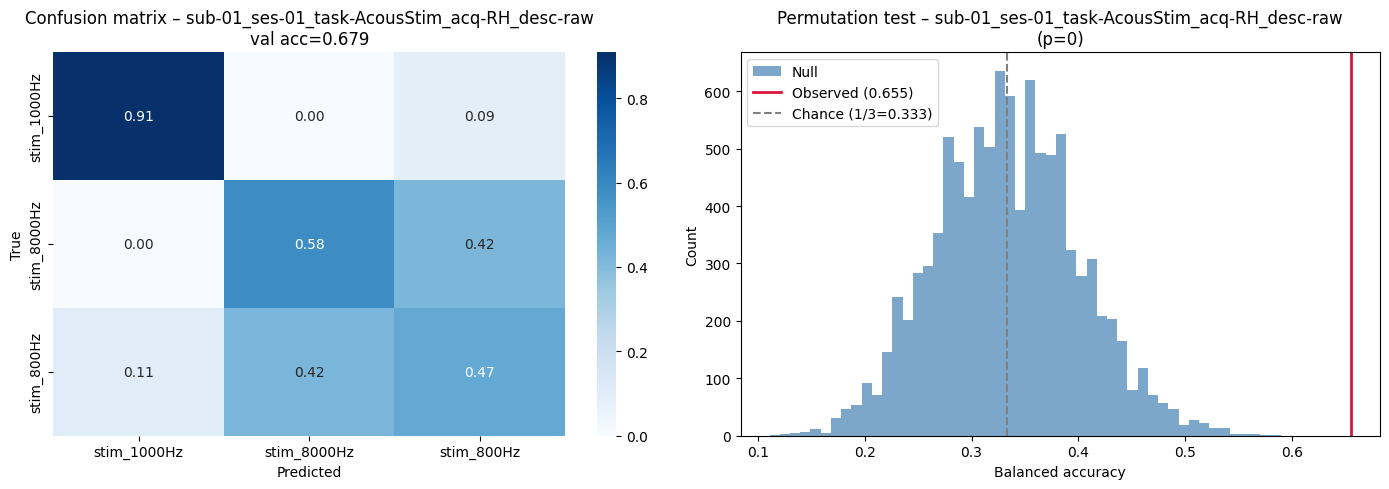


Recording: sub-01_ses-02_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 737/737 [00:04<00:00, 179.72it/s]
Skipping 2.0000 seconds of data due to short intervals. Remaining: 366.5 seconds.
Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 119/119 [00:00<00:00, 178.78it/s]


  train: X=(733, 1000, 29)  y=(733,)
  valid: X=(119, 1000, 29)  y=(119,)
  Feature shapes: train (733, 14529)  valid (119, 14529)
  Validation accuracy: 0.639
  Balanced accuracy:   0.624

              precision    recall  f1-score   support

stim_10000Hz       0.55      0.92      0.69        12
 stim_1000Hz       0.60      0.50      0.55        12
stim_16000Hz       0.92      1.00      0.96        11
stim_20000Hz       0.44      0.58      0.50        12
 stim_2000Hz       0.00      0.00      0.00        11
  stim_200Hz       0.43      0.55      0.48        11
 stim_5000Hz       0.88      0.94      0.91        16
  stim_500Hz       0.75      0.27      0.40        11
 stim_8000Hz       1.00      0.67      0.80        12
  stim_800Hz       0.69      0.82      0.75        11

    accuracy                           0.64       119
   macro avg       0.63      0.62      0.60       119
weighted avg       0.64      0.64      0.62       119

  Binomial p-value   : 6.367e-37  (H0: acc ≤ 0.134)

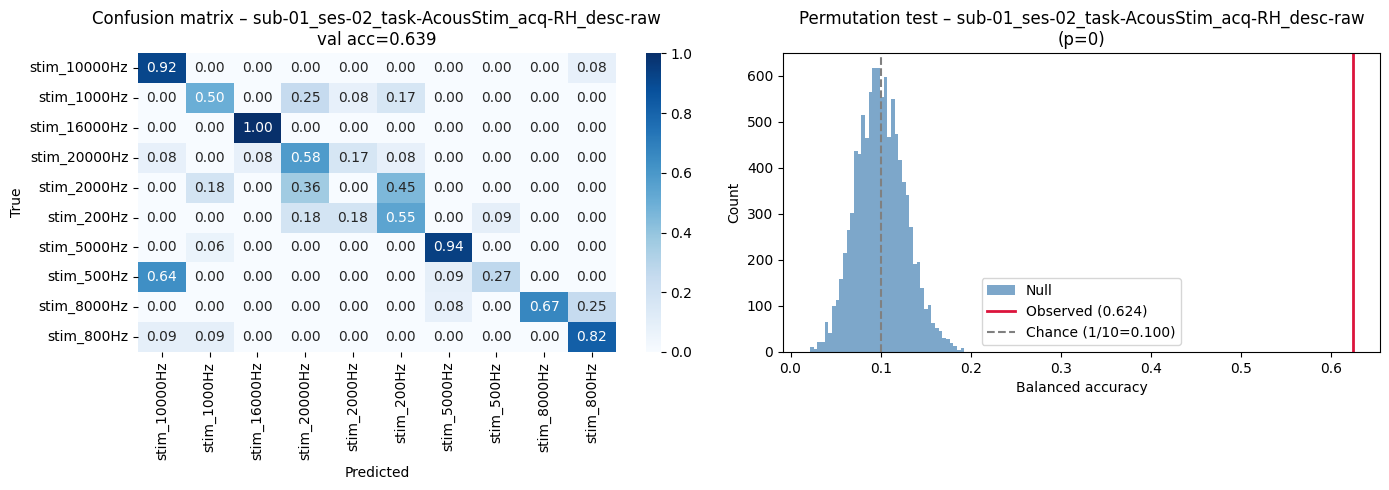


Recording: sub-01_ses-03_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 827/827 [00:05<00:00, 157.77it/s]
Skipping 1.5000 seconds of data due to short intervals. Remaining: 412.0 seconds.
Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 133/133 [00:00<00:00, 156.91it/s]


  train: X=(824, 1000, 29)  y=(824,)
  valid: X=(133, 1000, 29)  y=(133,)
  Feature shapes: train (824, 14529)  valid (133, 14529)
  Validation accuracy: 0.519
  Balanced accuracy:   0.387

              precision    recall  f1-score   support

stim_10000Hz       0.50      0.17      0.25         6
 stim_1000Hz       0.25      0.12      0.17         8
  stim_100Hz       0.50      0.17      0.25         6
stim_16000Hz       0.00      0.00      0.00         6
stim_20000Hz       0.17      0.17      0.17         6
 stim_2000Hz       0.38      1.00      0.55         9
  stim_200Hz       0.36      0.50      0.42         8
 stim_3000Hz       0.00      0.00      0.00         5
  stim_300Hz       0.67      0.40      0.50         5
 stim_4000Hz       1.00      0.14      0.25         7
  stim_400Hz       0.00      0.00      0.00         6
 stim_5000Hz       0.78      0.88      0.82         8
  stim_500Hz       1.00      0.67      0.80         6
 stim_8000Hz       0.50      0.17      0.25         6

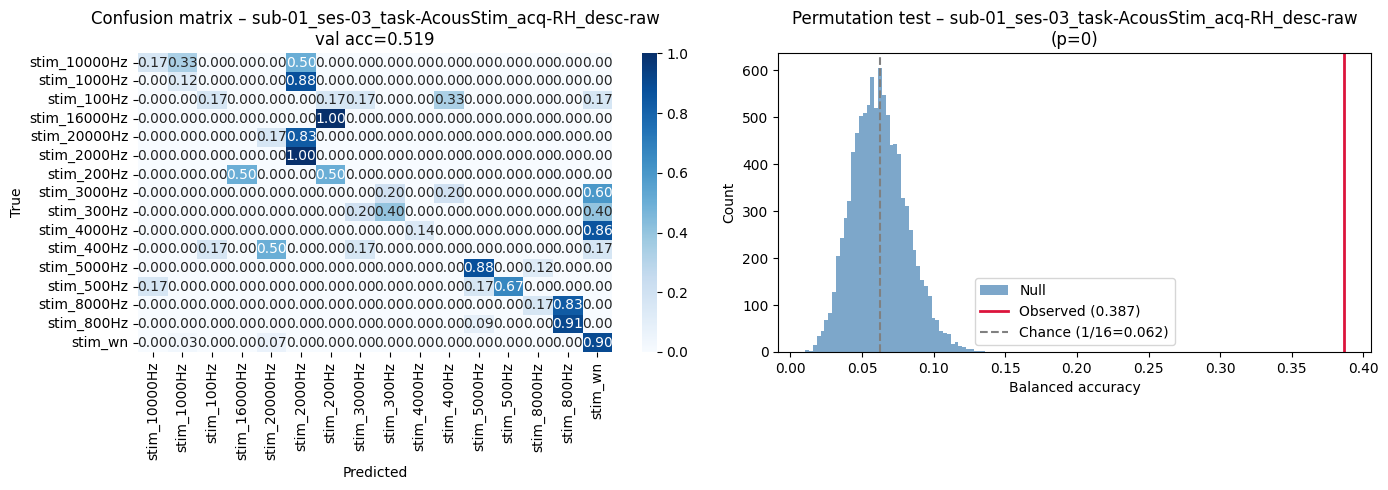


Recording: sub-01_ses-04_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1117/1117 [00:09<00:00, 118.88it/s]
Skipping 2.0000 seconds of data due to short intervals. Remaining: 556.5 seconds.
Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 179/179 [00:01<00:00, 118.41it/s]


  train: X=(1113, 1000, 29)  y=(1113,)
  valid: X=(179, 1000, 29)  y=(179,)
  Feature shapes: train (1113, 14529)  valid (179, 14529)
  Validation accuracy: 0.413
  Balanced accuracy:   0.412

              precision    recall  f1-score   support

stim_10000Hz       0.67      0.36      0.47        11
 stim_1000Hz       0.30      0.25      0.27        12
  stim_100Hz       0.52      0.86      0.65        14
stim_12000Hz       0.25      0.18      0.21        11
stim_16000Hz       0.00      0.00      0.00        14
stim_20000Hz       0.25      0.09      0.13        11
 stim_2000Hz       0.92      1.00      0.96        11
  stim_200Hz       0.80      1.00      0.89        12
  stim_300Hz       0.50      0.27      0.35        11
 stim_4000Hz       0.33      0.58      0.42        12
  stim_400Hz       0.12      0.08      0.10        12
 stim_5000Hz       0.17      0.17      0.17        12
  stim_500Hz       0.17      0.33      0.22        12
 stim_8000Hz       0.41      0.58      0.48       

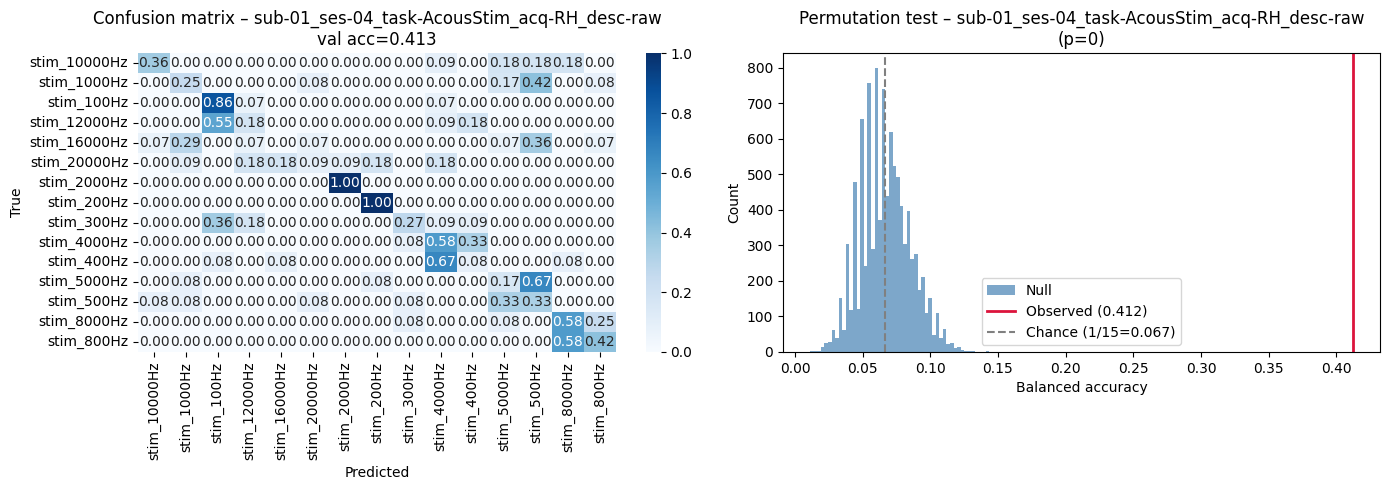


Recording: sub-01_ses-05_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44/44 [00:00<00:00, 476.08it/s]


  train: X=(266, 1000, 29)  y=(266,)
  valid: X=(44, 1000, 29)  y=(44,)
  Feature shapes: train (266, 14529)  valid (44, 14529)
  Validation accuracy: 1.000
  Balanced accuracy:   1.000

              precision    recall  f1-score   support

stim_10000Hz       1.00      1.00      1.00        13
  stim_500Hz       1.00      1.00      1.00        15
  stim_800Hz       1.00      1.00      1.00        16

    accuracy                           1.00        44
   macro avg       1.00      1.00      1.00        44
weighted avg       1.00      1.00      1.00        44

  Binomial p-value   : 4.67e-20  (H0: acc ≤ 0.364)
  Permutation p-value: 0


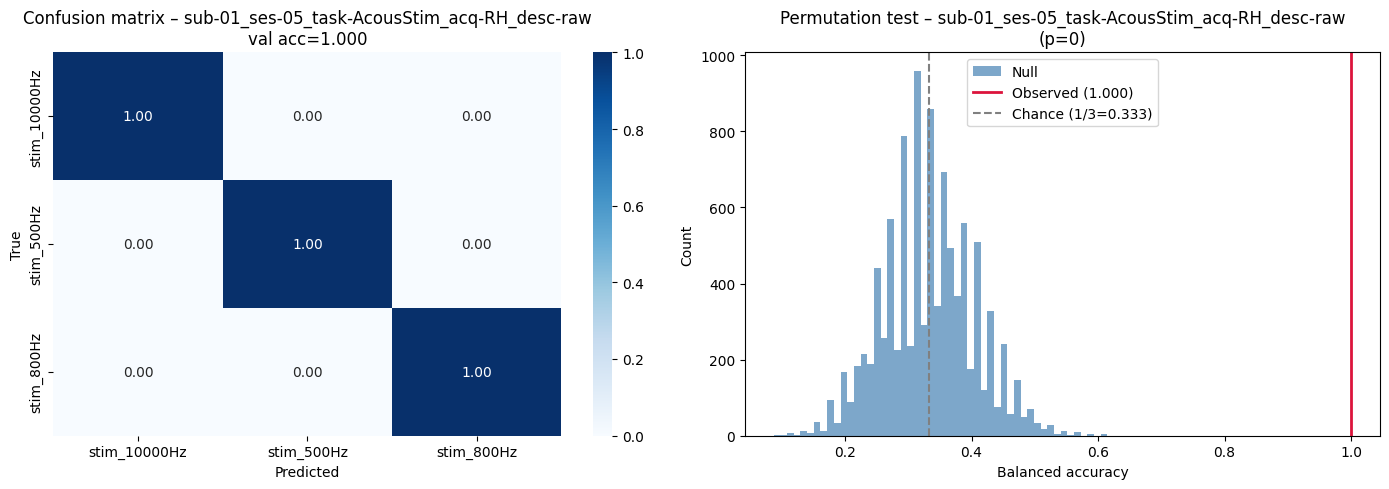


Recording: sub-01_ses-06_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 49/49 [00:00<00:00, 416.82it/s]


  train: X=(306, 1000, 29)  y=(306,)
  valid: X=(49, 1000, 29)  y=(49,)
  Feature shapes: train (306, 14529)  valid (49, 14529)
  Validation accuracy: 0.306
  Balanced accuracy:   0.264

              precision    recall  f1-score   support

 stim_1000Hz       0.29      0.17      0.21        12
  stim_100Hz       0.44      0.33      0.38        12
 stim_2000Hz       0.25      0.45      0.32        11
  stim_300Hz       0.00      0.00      0.00         3
 stim_8000Hz       0.31      0.36      0.33        11

    accuracy                           0.31        49
   macro avg       0.26      0.26      0.25        49
weighted avg       0.30      0.31      0.29        49



/capstor/scratch/cscs/awgolab/mila_test/auditorydecoding/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/capstor/scratch/cscs/awgolab/mila_test/auditorydecoding/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/capstor/scratch/cscs/awgolab/mila_test/auditorydecoding/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

  Binomial p-value   : 0.2006  (H0: acc ≤ 0.245)
  Permutation p-value: 0.116


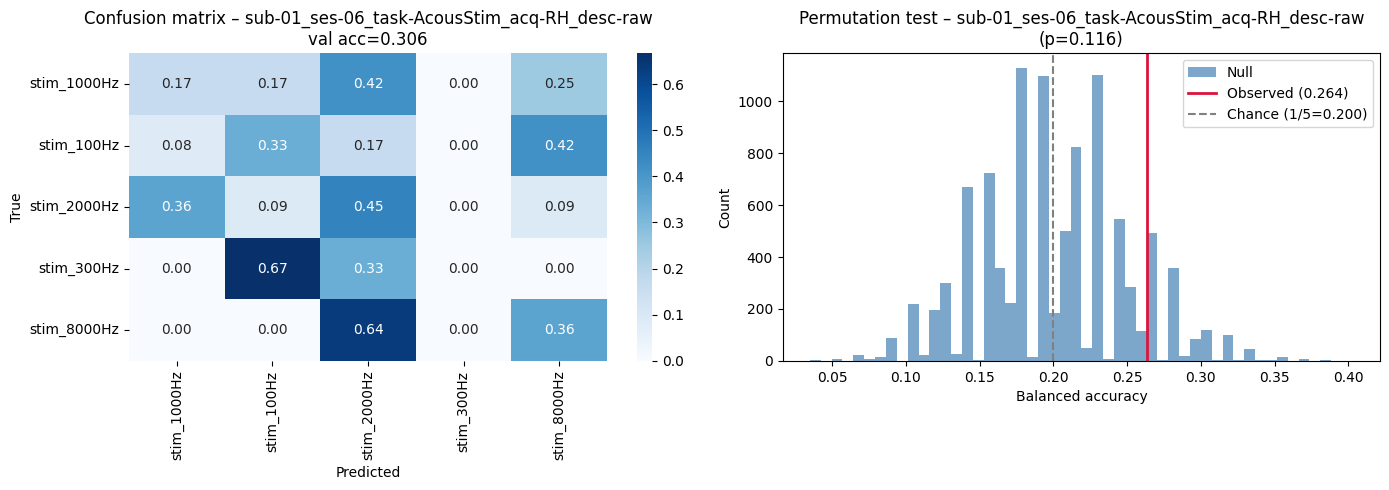


Recording: sub-01_ses-07_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 198/198 [00:02<00:00, 95.30it/s]


  train: X=(1232, 1000, 29)  y=(1232,)
  valid: X=(198, 1000, 29)  y=(198,)
  Feature shapes: train (1232, 14529)  valid (198, 14529)
  Validation accuracy: 0.348
  Balanced accuracy:   0.311

              precision    recall  f1-score   support

stim_10000Hz       0.22      0.18      0.20        11
 stim_1000Hz       0.30      0.27      0.29        11
  stim_100Hz       0.21      0.33      0.26         9
stim_12000Hz       0.33      0.25      0.29        12
 stim_1500Hz       0.00      0.00      0.00        12
stim_20000Hz       0.26      0.36      0.30        14
 stim_2000Hz       0.38      0.27      0.32        11
  stim_200Hz       1.00      0.36      0.53        11
 stim_3000Hz       0.29      0.33      0.31        12
  stim_300Hz       0.00      0.00      0.00         5
 stim_4000Hz       0.18      0.17      0.17        12
  stim_400Hz       0.25      0.27      0.26        11
 stim_5000Hz       0.30      0.27      0.29        11
  stim_500Hz       0.54      0.70      0.61       

/capstor/scratch/cscs/awgolab/mila_test/auditorydecoding/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/capstor/scratch/cscs/awgolab/mila_test/auditorydecoding/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/capstor/scratch/cscs/awgolab/mila_test/auditorydecoding/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

  Binomial p-value   : 8.44e-16  (H0: acc ≤ 0.126)
  Permutation p-value: 0


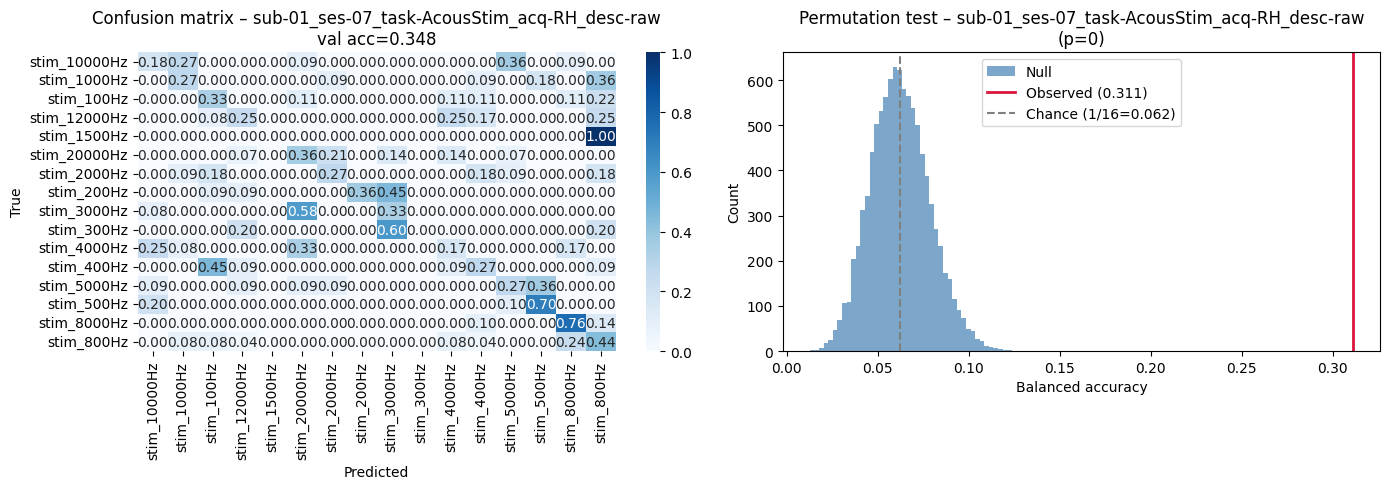


Recording: sub-01_ses-08_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1176/1176 [00:10<00:00, 111.58it/s]
Skipping 0.5000 seconds of data due to short intervals. Remaining: 587.5 seconds.
Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 191/191 [00:01<00:00, 111.27it/s]


  train: X=(1175, 1000, 29)  y=(1175,)
  valid: X=(191, 1000, 29)  y=(191,)
  Feature shapes: train (1175, 14529)  valid (191, 14529)
  Validation accuracy: 0.209
  Balanced accuracy:   0.204

              precision    recall  f1-score   support

stim_10000Hz       0.17      0.25      0.20        12
 stim_1000Hz       0.00      0.00      0.00        12
  stim_100Hz       0.20      0.08      0.12        12
stim_12000Hz       0.27      0.47      0.34        15
stim_16000Hz       0.17      0.17      0.17        12
stim_20000Hz       0.00      0.00      0.00        12
 stim_2000Hz       0.20      0.27      0.23        11
  stim_200Hz       0.70      0.58      0.64        12
 stim_3000Hz       0.21      0.25      0.23        12
  stim_300Hz       0.00      0.00      0.00        12
 stim_4000Hz       0.12      0.08      0.10        12
  stim_400Hz       0.07      0.09      0.08        11
 stim_5000Hz       0.29      0.17      0.21        12
  stim_500Hz       0.14      0.09      0.11       

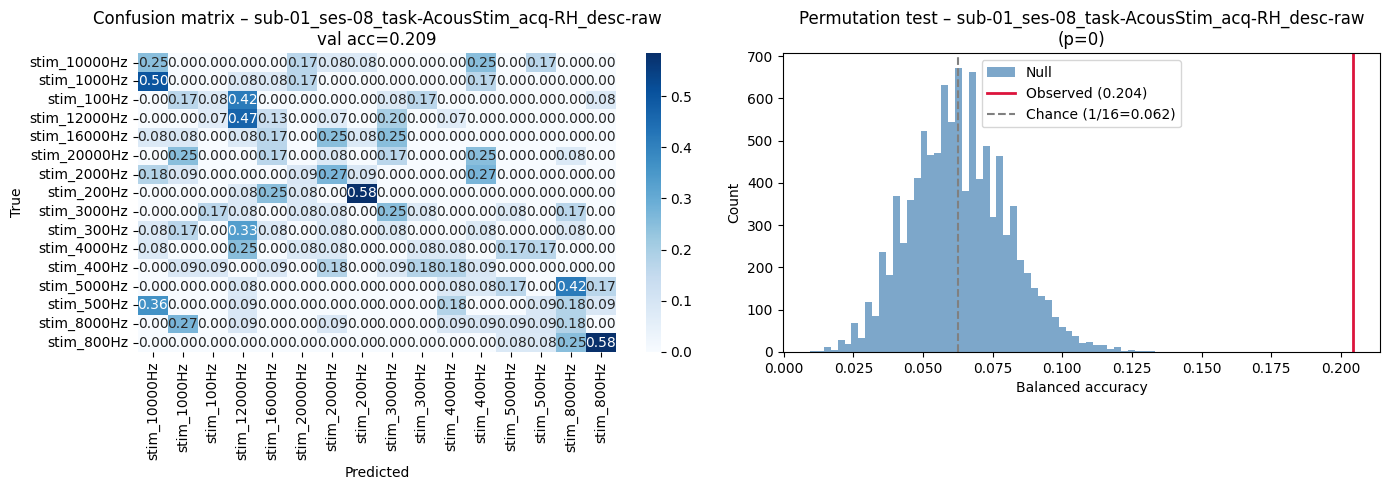


Recording: sub-01_ses-09_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 354/354 [00:00<00:00, 368.93it/s]
Skipping 0.5000 seconds of data due to short intervals. Remaining: 176.5 seconds.
Extracting windows: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 56/56 [00:00<00:00, 363.97it/s]


  train: X=(353, 1000, 29)  y=(353,)
  valid: X=(56, 1000, 29)  y=(56,)
  Feature shapes: train (353, 14529)  valid (56, 14529)
  Validation accuracy: 0.786
  Balanced accuracy:   0.789

              precision    recall  f1-score   support

stim_10000Hz       0.90      0.82      0.86        11
stim_20000Hz       1.00      0.91      0.95        11
  stim_200Hz       0.80      0.73      0.76        11
 stim_5000Hz       0.62      0.91      0.74        11
  stim_800Hz       0.70      0.58      0.64        12

    accuracy                           0.79        56
   macro avg       0.81      0.79      0.79        56
weighted avg       0.80      0.79      0.79        56

  Binomial p-value   : 1.22e-19  (H0: acc ≤ 0.214)
  Permutation p-value: 0


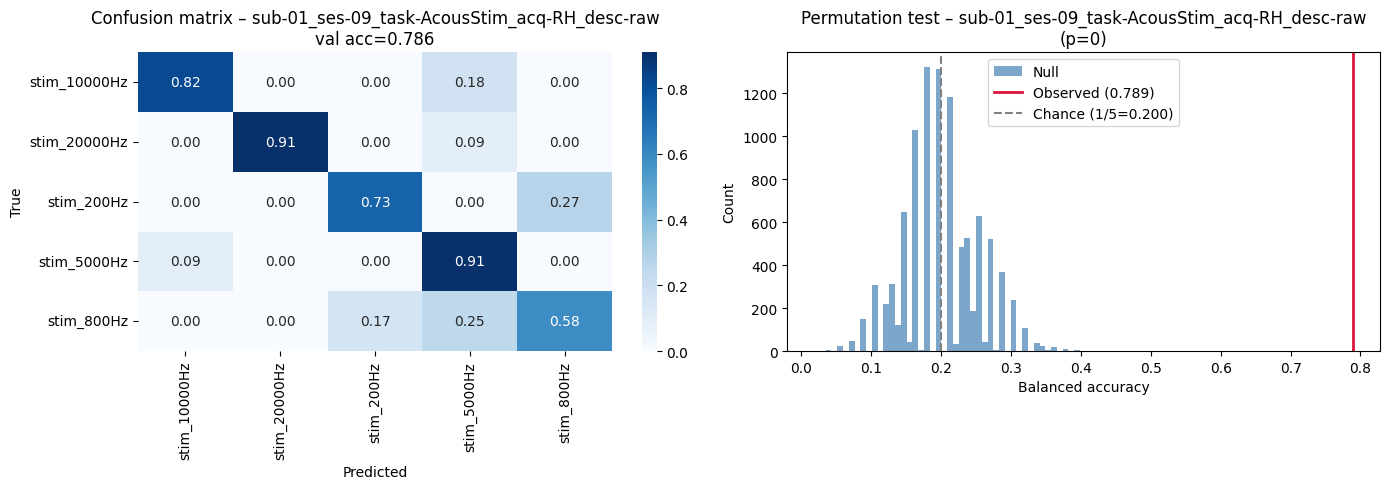


Recording: sub-02_ses-01_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 334/334 [00:05<00:00, 60.22it/s]


  train: X=(2068, 1000, 29)  y=(2068,)
  valid: X=(334, 1000, 29)  y=(334,)
  Feature shapes: train (2068, 14529)  valid (334, 14529)
  Validation accuracy: 0.560
  Balanced accuracy:   0.378

              precision    recall  f1-score   support

stim_10000Hz       0.62      0.86      0.72       196
 stim_2000Hz       0.35      0.12      0.17        69
 stim_5000Hz       0.28      0.16      0.20        69

    accuracy                           0.56       334
   macro avg       0.42      0.38      0.37       334
weighted avg       0.49      0.56      0.50       334

  Binomial p-value   : 0.8544  (H0: acc ≤ 0.587)
  Permutation p-value: 0.0121


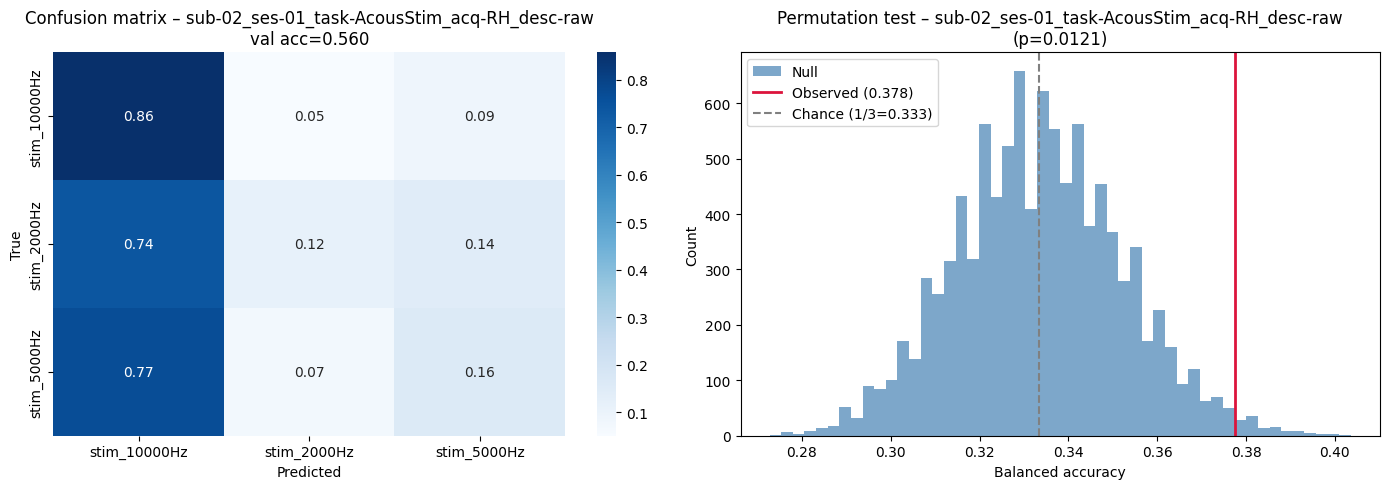


Recording: sub-02_ses-02_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3193/3193 [01:26<00:00, 36.82it/s]
Skipping 2.0000 seconds of data due to short intervals. Remaining: 1594.5 seconds.
Extracting windows: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 516/516 [00:14<00:00, 36.71it/s]


  train: X=(3189, 1000, 29)  y=(3189,)
  valid: X=(516, 1000, 29)  y=(516,)
  Feature shapes: train (3189, 14529)  valid (516, 14529)
  Validation accuracy: 0.370
  Balanced accuracy:   0.227

              precision    recall  f1-score   support

stim_10000Hz       0.00      0.00      0.00        11
 stim_1000Hz       0.41      0.42      0.42        80
stim_12000Hz       0.00      0.00      0.00        12
stim_16000Hz       0.00      0.00      0.00        12
stim_20000Hz       0.33      0.31      0.32        83
 stim_2000Hz       0.30      0.34      0.32        58
 stim_3000Hz       0.00      0.00      0.00        12
  stim_300Hz       0.42      0.48      0.45        88
 stim_5000Hz       0.32      0.54      0.41        68
 stim_8000Hz       0.44      0.40      0.42        81
  stim_800Hz       0.00      0.00      0.00        11

    accuracy                           0.37       516
   macro avg       0.20      0.23      0.21       516
weighted avg       0.33      0.37      0.35      

/capstor/scratch/cscs/awgolab/mila_test/auditorydecoding/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/capstor/scratch/cscs/awgolab/mila_test/auditorydecoding/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/capstor/scratch/cscs/awgolab/mila_test/auditorydecoding/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

  Binomial p-value   : 2.095e-27  (H0: acc ≤ 0.171)
  Permutation p-value: 0


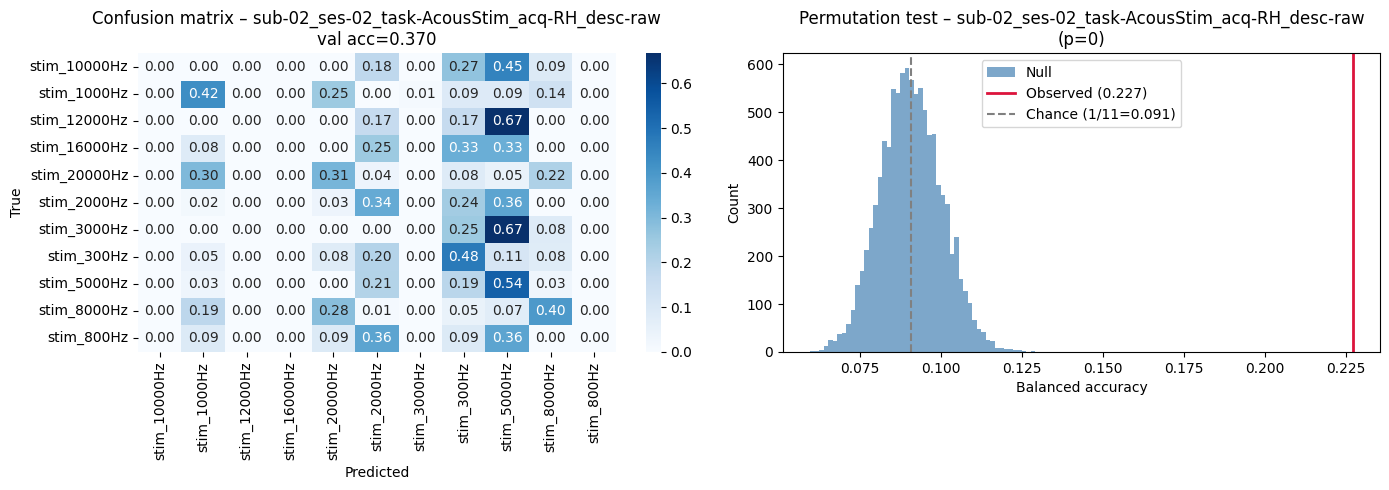


Recording: sub-02_ses-03_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 890/890 [00:05<00:00, 148.40it/s]
Skipping 0.5000 seconds of data due to short intervals. Remaining: 444.5 seconds.
Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 145/145 [00:00<00:00, 148.07it/s]


  train: X=(889, 1000, 29)  y=(889,)
  valid: X=(145, 1000, 29)  y=(145,)
  Feature shapes: train (889, 14529)  valid (145, 14529)
  Validation accuracy: 0.786
  Balanced accuracy:   0.787

              precision    recall  f1-score   support

stim_12000Hz       0.82      0.74      0.78        73
 stim_3000Hz       0.76      0.83      0.79        72

    accuracy                           0.79       145
   macro avg       0.79      0.79      0.79       145
weighted avg       0.79      0.79      0.79       145

  Binomial p-value   : 2.086e-12  (H0: acc ≤ 0.503)
  Permutation p-value: 0


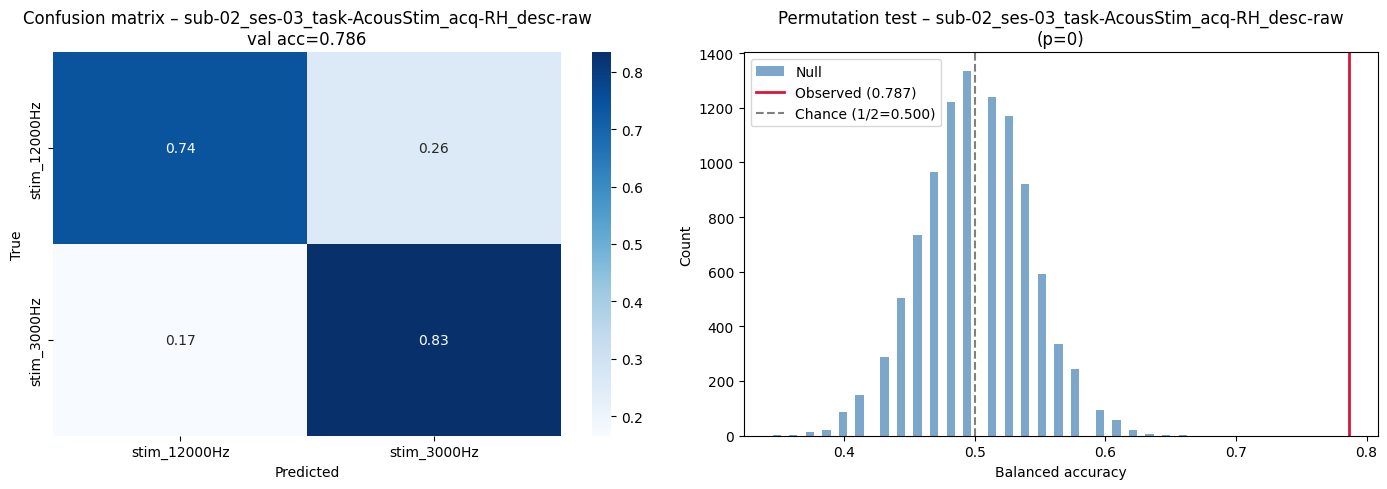


Recording: sub-02_ses-04_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 61/61 [00:00<00:00, 352.50it/s]
/capstor/scratch/cscs/awgolab/mila_test/auditorydecoding/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/capstor/scratch/cscs/awgolab/mila_test/auditorydecoding/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/capstor/scratch/cscs/awgolab/mila_test/auditorydeco

  train: X=(369, 1000, 29)  y=(369,)
  valid: X=(61, 1000, 29)  y=(61,)
  Feature shapes: train (369, 14529)  valid (61, 14529)
  Validation accuracy: 0.803
  Balanced accuracy:   0.500

              precision    recall  f1-score   support

stim_12000Hz       0.00      0.00      0.00        12
stim_16000Hz       0.80      1.00      0.89        49

    accuracy                           0.80        61
   macro avg       0.40      0.50      0.45        61
weighted avg       0.65      0.80      0.72        61

  Binomial p-value   : 0.5764  (H0: acc ≤ 0.803)
  Permutation p-value: 1


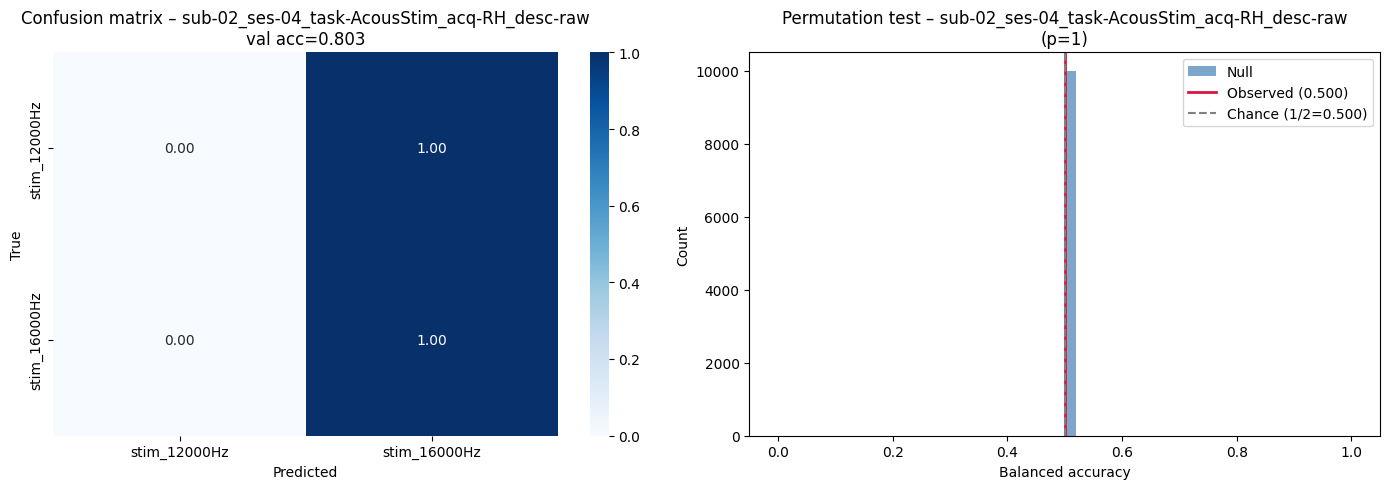


Recording: sub-02_ses-05_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 59/59 [00:00<00:00, 1913.50it/s]
Skipping 0.5000 seconds of data due to short intervals. Remaining: 29.0 seconds.
Extracting windows: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 1831.84it/s]

  train: X=(58, 1000, 29)  y=(58,)
  valid: X=(9, 1000, 29)  y=(9,)
  Feature shapes: train (58, 14529)  valid (9, 14529)

[ERROR] sub-02_ses-05_task-AcousStim_acq-RH_desc-raw: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(0)

Recording: sub-03_ses-01_task-AcousStim_acq-RH_desc-raw



Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 524/524 [00:02<00:00, 251.31it/s]
Skipping 0.5000 seconds of data due to short intervals. Remaining: 261.5 seconds.
Extracting windows: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 86/86 [00:00<00:00, 250.36it/s]


  train: X=(523, 1000, 29)  y=(523,)
  valid: X=(86, 1000, 29)  y=(86,)
  Feature shapes: train (523, 14529)  valid (86, 14529)
  Validation accuracy: 0.477
  Balanced accuracy:   0.454

              precision    recall  f1-score   support

stim_10000Hz       0.50      0.43      0.46        14
 stim_1000Hz       0.38      0.27      0.32        11
stim_20000Hz       0.75      0.50      0.60        12
 stim_2000Hz       0.53      0.67      0.59        12
 stim_5000Hz       0.42      0.62      0.50        24
  stim_500Hz       0.43      0.23      0.30        13

    accuracy                           0.48        86
   macro avg       0.50      0.45      0.46        86
weighted avg       0.49      0.48      0.47        86

  Binomial p-value   : 7.683e-05  (H0: acc ≤ 0.279)
  Permutation p-value: 0


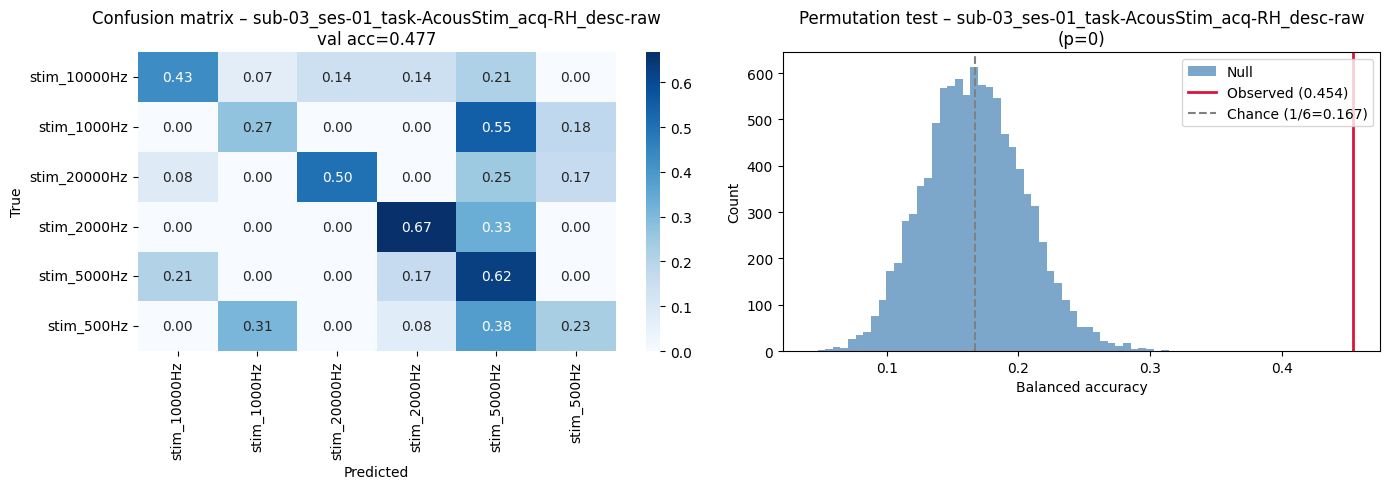


Recording: sub-04_ses-01_task-AcousStim_acq-LH_desc-raw


Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 678/678 [00:03<00:00, 196.41it/s]
Skipping 1.0000 seconds of data due to short intervals. Remaining: 338.0 seconds.
Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 111/111 [00:00<00:00, 195.33it/s]


  train: X=(676, 1000, 29)  y=(676,)
  valid: X=(111, 1000, 29)  y=(111,)
  Feature shapes: train (676, 14529)  valid (111, 14529)
  Validation accuracy: 0.829
  Balanced accuracy:   0.761

              precision    recall  f1-score   support

stim_10000Hz       0.82      0.45      0.58        20
 stim_1000Hz       0.95      1.00      0.97        18
 stim_5000Hz       0.79      0.98      0.88        55
  stim_500Hz       0.85      0.61      0.71        18

    accuracy                           0.83       111
   macro avg       0.85      0.76      0.79       111
weighted avg       0.83      0.83      0.81       111

  Binomial p-value   : 2.885e-13  (H0: acc ≤ 0.495)
  Permutation p-value: 0


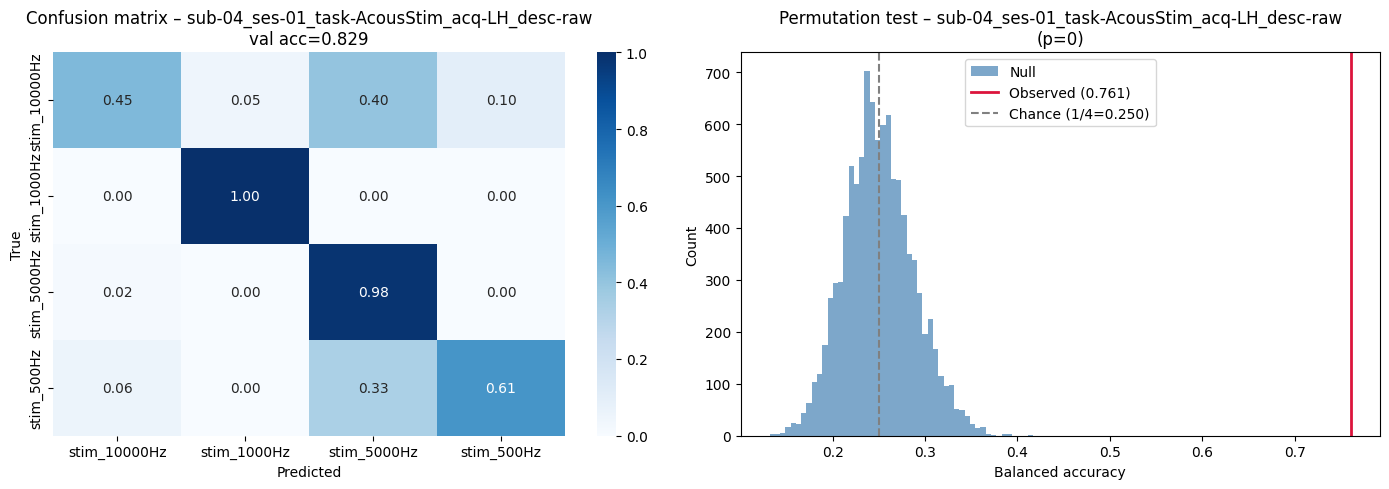


Recording: sub-04_ses-01_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:04<00:00, 70.78it/s]


  train: X=(1811, 1000, 29)  y=(1811,)
  valid: X=(296, 1000, 29)  y=(296,)
  Feature shapes: train (1811, 14529)  valid (296, 14529)
  Validation accuracy: 0.534
  Balanced accuracy:   0.445

              precision    recall  f1-score   support

stim_10000Hz       0.68      0.57      0.62        83
 stim_1000Hz       0.73      0.66      0.69        50
 stim_2000Hz       0.27      0.33      0.30        30
  stim_300Hz       1.00      0.17      0.29        18
 stim_5000Hz       0.70      0.75      0.72        64
  stim_500Hz       0.24      0.36      0.29        33
  stim_800Hz       0.21      0.28      0.24        18

    accuracy                           0.53       296
   macro avg       0.55      0.45      0.45       296
weighted avg       0.59      0.53      0.54       296

  Binomial p-value   : 4.834e-20  (H0: acc ≤ 0.280)
  Permutation p-value: 0


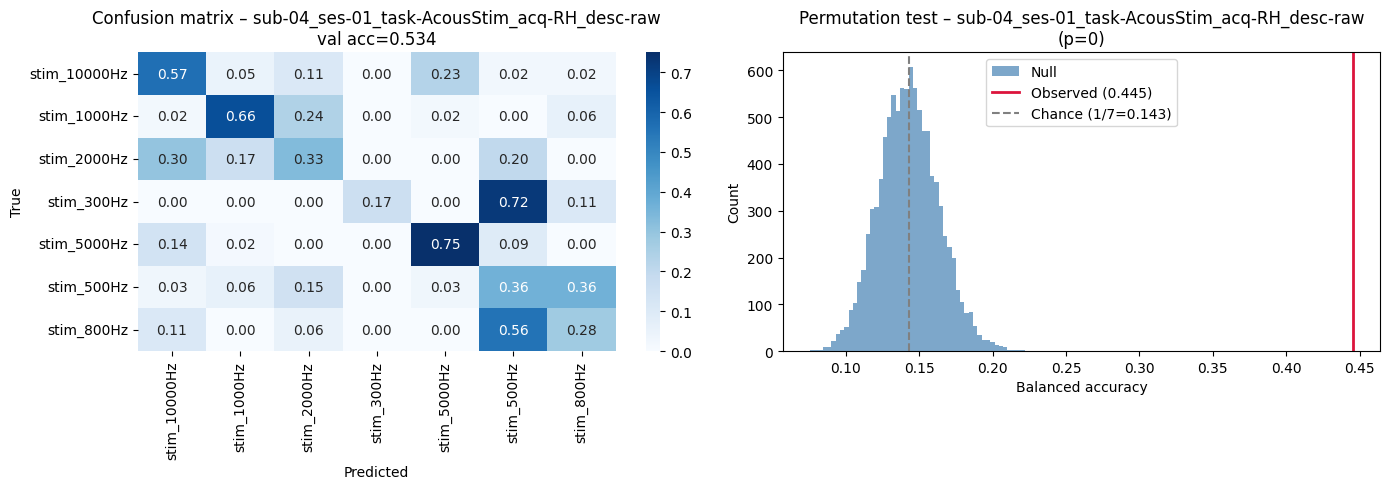


Recording: sub-05_ses-01_task-AcousStim_acq-LH_desc-raw


Extracting windows: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [00:00<00:00, 303.48it/s]


  train: X=(360, 1000, 29)  y=(360,)
  valid: X=(56, 1000, 29)  y=(56,)
  Feature shapes: train (360, 14529)  valid (56, 14529)
  Validation accuracy: 0.661
  Balanced accuracy:   0.653

              precision    recall  f1-score   support

 stim_1000Hz       0.66      0.77      0.71        30
 stim_5000Hz       0.67      0.54      0.60        26

    accuracy                           0.66        56
   macro avg       0.66      0.65      0.65        56
weighted avg       0.66      0.66      0.66        56

  Binomial p-value   : 0.03973  (H0: acc ≤ 0.536)
  Permutation p-value: 0.018


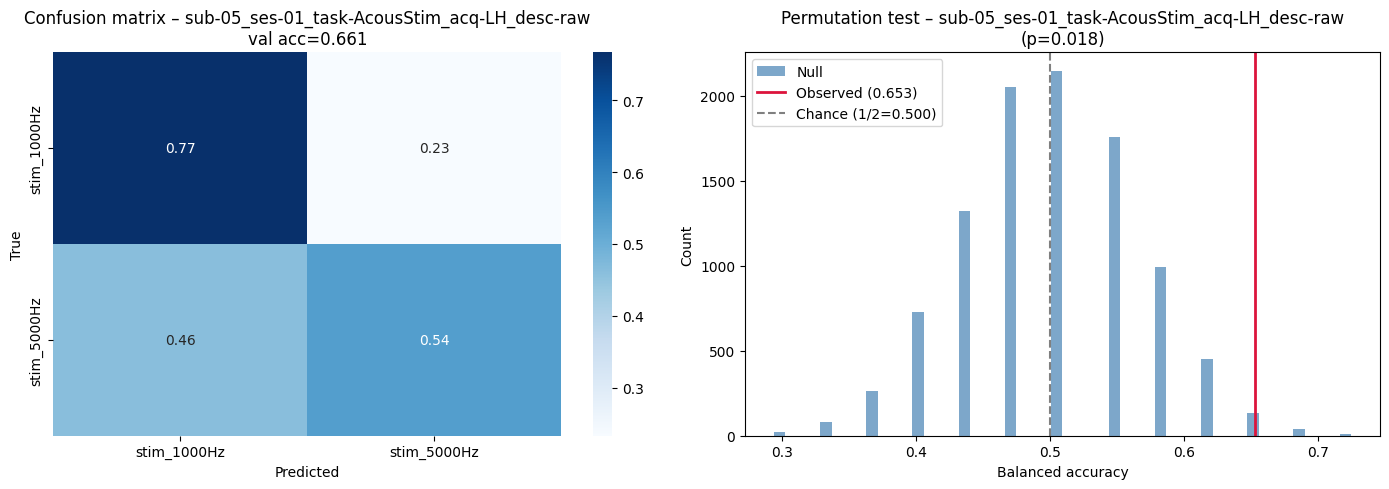


Recording: sub-05_ses-01_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1735/1735 [00:15<00:00, 114.45it/s]
Skipping 74.0000 seconds of data due to short intervals. Remaining: 615.0 seconds.
Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 286/286 [00:02<00:00, 115.52it/s]
Skipping 12.0000 seconds of data due to short intervals. Remaining: 100.8 seconds.


  train: X=(1449, 1000, 29)  y=(1449,)
  valid: X=(237, 1000, 29)  y=(237,)
  Feature shapes: train (1449, 14529)  valid (237, 14529)
  Validation accuracy: 0.785
  Balanced accuracy:   0.771

              precision    recall  f1-score   support

stim_10000Hz       0.80      0.75      0.77        16
 stim_1000Hz       0.80      0.83      0.81        47
 stim_2000Hz       0.85      0.93      0.89        44
  stim_300Hz       0.90      0.79      0.84        34
 stim_5000Hz       0.79      0.73      0.76        30
  stim_500Hz       0.71      0.69      0.70        36
  stim_800Hz       0.62      0.67      0.65        30

    accuracy                           0.78       237
   macro avg       0.78      0.77      0.78       237
weighted avg       0.79      0.78      0.78       237

  Binomial p-value   : 6.925e-84  (H0: acc ≤ 0.198)
  Permutation p-value: 0


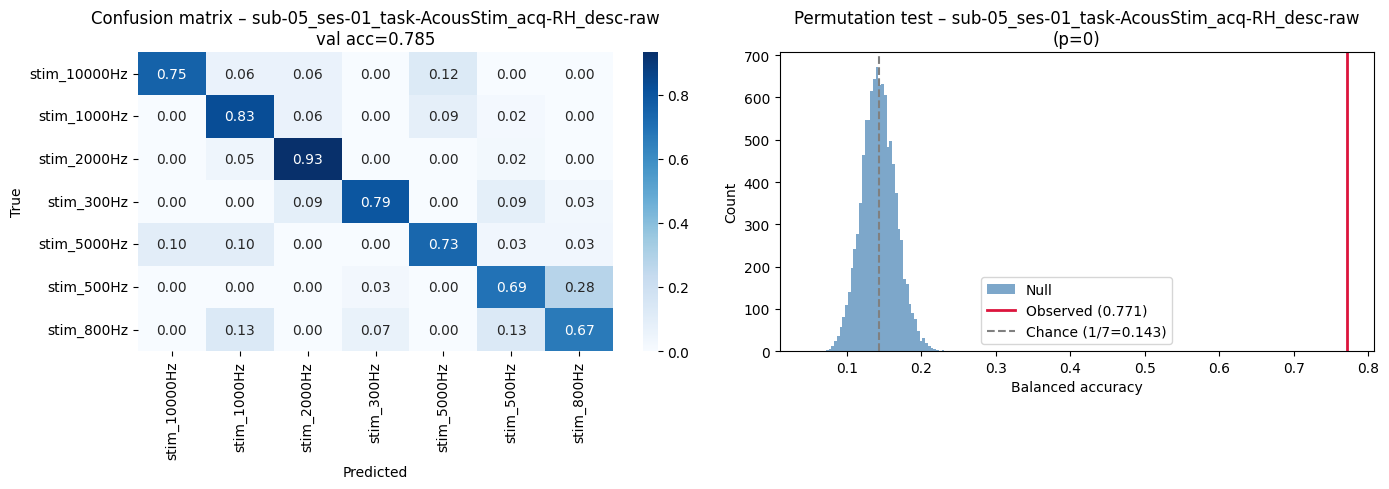


Recording: sub-06_ses-01_task-AcousStim_acq-RH_desc-raw


Extracting windows: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:00<00:00, 174.82it/s]


  train: X=(368, 1000, 29)  y=(368,)
  valid: X=(58, 1000, 29)  y=(58,)
  Feature shapes: train (368, 14529)  valid (58, 14529)
  Validation accuracy: 0.638
  Balanced accuracy:   0.655

              precision    recall  f1-score   support

 stim_1000Hz       0.62      0.62      0.62        24
 stim_5000Hz       0.57      0.59      0.58        22
  stim_800Hz       0.82      0.75      0.78        12

    accuracy                           0.64        58
   macro avg       0.67      0.66      0.66        58
weighted avg       0.64      0.64      0.64        58

  Binomial p-value   : 0.0004764  (H0: acc ≤ 0.414)
  Permutation p-value: 0


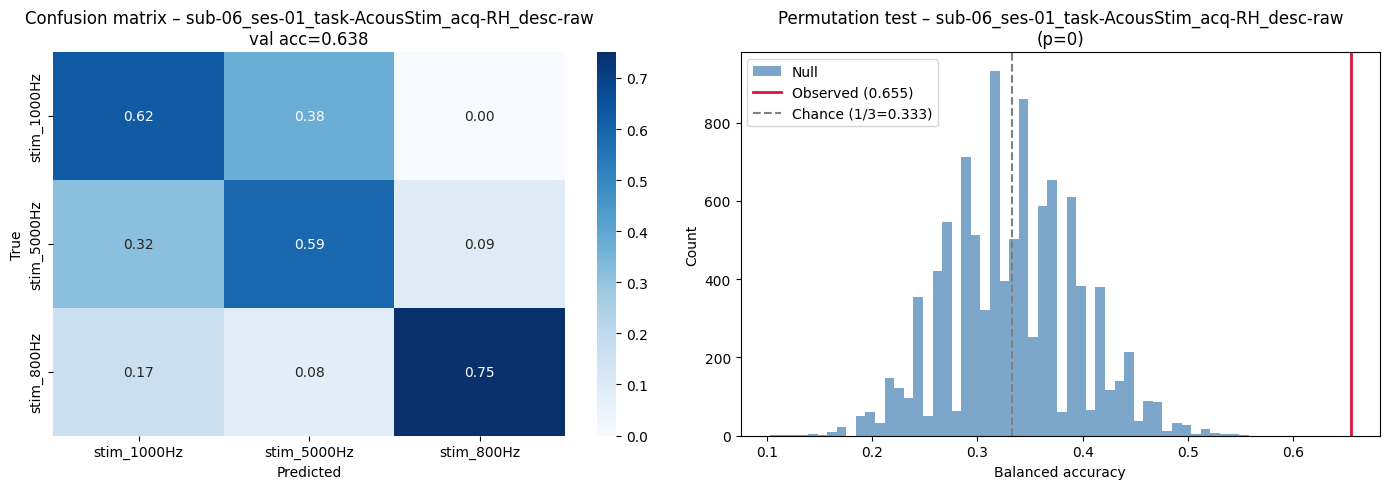


Finished 27 recordings.


In [20]:
all_results = []

for path in ALL_RECORDING_PATHS:
    try:
        result = run_decoding_for_recording(path, CFG)
        all_results.append(result)
    except Exception as e:
        recording_id = os.path.splitext(os.path.basename(path))[0]
        print(f"\n[ERROR] {recording_id}: {e}")
        all_results.append({"recording_id": recording_id, "error": str(e)})

print(f"\nFinished {len(all_results)} recordings.")

## Summary across all monkeys

In [21]:
import pandas as pd

successful = [r for r in all_results if "error" not in r]
failed     = [r for r in all_results if "error" in r]

if failed:
    print("Failed recordings:")
    for r in failed:
        print(f"  {r['recording_id']}: {r['error']}")
    print()

df = pd.DataFrame(successful)[[
    "recording_id", "n_channels", "n_train", "n_valid",
    "n_classes", "majority_chance", "uniform_chance",
    "val_acc", "val_bal_acc", "binom_pvalue", "permutation_pvalue"
]]
df = df.set_index("recording_id")

display(df.round(4))

print(f"\nMean validation accuracy     : {df['val_acc'].mean():.3f} ± {df['val_acc'].std():.3f}")
print(f"Mean balanced accuracy       : {df['val_bal_acc'].mean():.3f} ± {df['val_bal_acc'].std():.3f}")
sig = (df['permutation_pvalue'] < 0.05).sum()
print(f"Significant (perm p<0.05)    : {sig}/{len(df)}")

Failed recordings:
  sub-02_ses-05_task-AcousStim_acq-RH_desc-raw: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(0)



,n_channels,n_train,n_valid,n_classes,majority_chance,uniform_chance,val_acc,val_bal_acc,binom_pvalue,permutation_pvalue
recording_id,,,,,,,,,,
sub-01_ses-010_task-AcousStim_acq-RH_desc-raw,29,1260,205,7,0.2976,0.1429,0.4390,0.3719,0.0000,0.0000
sub-01_ses-011_task-AcousStim_acq-RH_desc-raw,29,1823,296,13,0.1081,0.0769,0.2601,0.2298,0.0000,0.0000
sub-01_ses-012_task-AcousStim_acq-RH_desc-raw,29,352,56,5,0.2143,0.2000,0.3571,0.3576,0.0100,0.0033
sub-01_ses-013_task-AcousStim_acq-RH_desc-raw,29,621,100,9,0.1200,0.1111,0.2100,0.2098,0.0073,0.0022
sub-01_ses-014_task-AcousStim_acq-RH_desc-raw,29,943,154,9,0.2078,0.1111,0.3182,0.2196,0.0009,0.0000
sub-01_ses-015_task-AcousStim_acq-RH_desc-raw,29,713,116,9,0.2672,0.1111,0.3707,0.2363,0.0094,0.0000
sub-01_ses-016_task-AcousStim_acq-RH_desc-raw,29,143,23,2,0.5217,0.5000,0.6522,0.6553,0.1483,0.1400
sub-01_ses-01_task-AcousStim_acq-RH_desc-raw,29,332,53,3,0.4151,0.3333,0.6792,0.6554,0.0001,0.0000
sub-01_ses-02_task-AcousStim_acq-RH_desc-raw,29,733,119,10,0.1345,0.1000,0.6387,0.6241,0.0000,0.0000



Mean validation accuracy     : 0.537 ± 0.216
Mean balanced accuracy       : 0.483 ± 0.228
Significant (perm p<0.05)    : 23/26


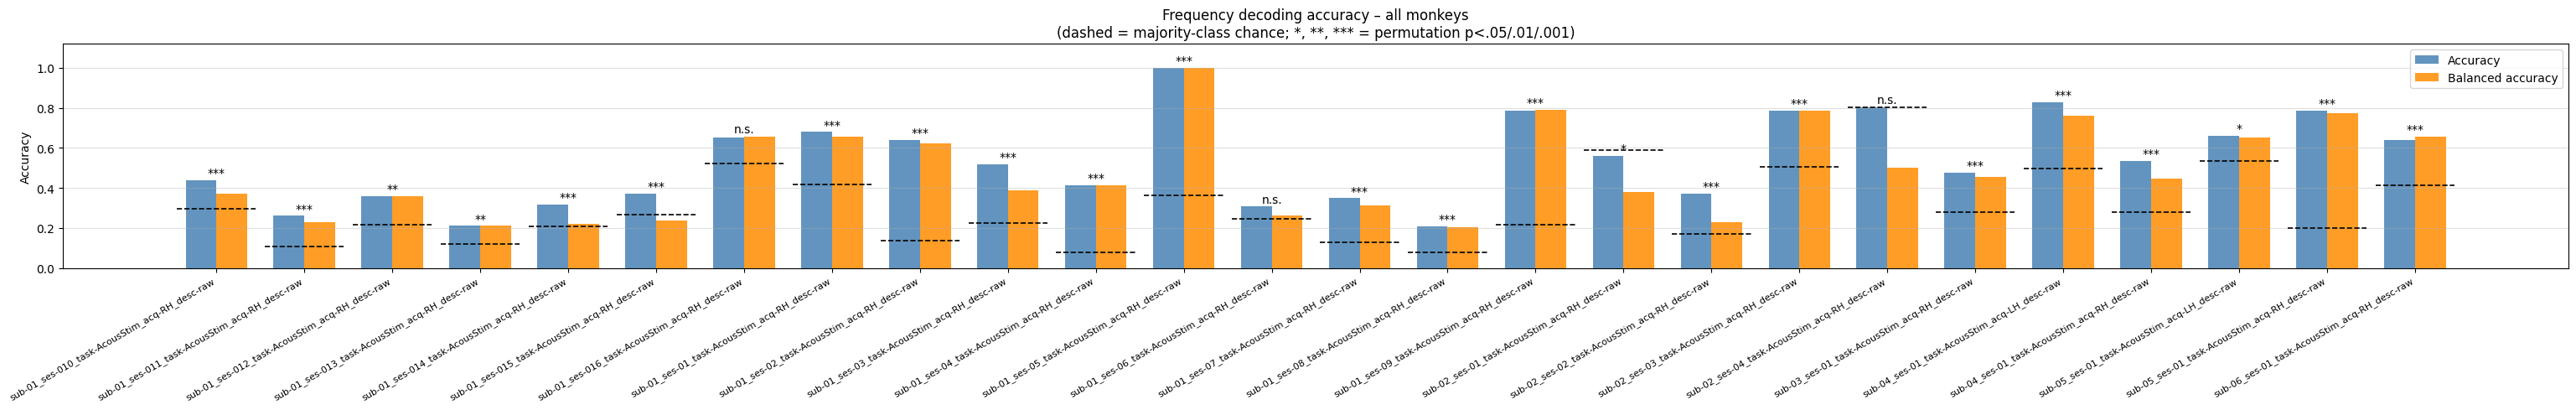

In [ ]:
fig, ax = plt.subplots(figsize=(max(8, len(df) * 1.2), 5))

x = np.arange(len(df))
width = 0.35

bars1 = ax.bar(x - width/2, df["val_acc"],     width, label="Accuracy",          color="steelblue", alpha=0.85)
bars2 = ax.bar(x + width/2, df["val_bal_acc"], width, label="Balanced accuracy", color="darkorange", alpha=0.85)

# Chance lines — per-recording majority chance (varies by monkey)
for i, (idx, row) in enumerate(df.iterrows()):
    ax.hlines(row["majority_chance"], i - 0.45, i + 0.45,
              colors="black", linestyles="--", linewidths=1.2)

# Significance markers
for i, (idx, row) in enumerate(df.iterrows()):
    if row["permutation_pvalue"] < 0.001:
        marker = "***"
    elif row["permutation_pvalue"] < 0.01:
        marker = "**"
    elif row["permutation_pvalue"] < 0.05:
        marker = "*"
    else:
        marker = "n.s."
    ax.text(i, max(row["val_acc"], row["val_bal_acc"]) + 0.02, marker,
            ha="center", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(df.index, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.12)
ax.set_title("Frequency decoding accuracy - all monkeys\n(dashed = majority-class chance; *, **, *** = permutation p<.05/.01/.001)")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# Build shared label space from the union of all recordings' classes
all_classes = np.array(sorted(set(
    cls for r in successful for cls in r["le"].classes_
)))
shared_le = LabelEncoder().fit(all_classes)

all_X_train, all_X_valid = [], []
all_y_train, all_y_valid = [], []
all_y_pred  = []

for r in successful:
    # Z-score per feature using train statistics
    mu  = r["X_train"].mean(axis=0)
    std = r["X_train"].std(axis=0) + 1e-8
    Xtr = (r["X_train"] - mu) / std
    Xva = (r["X_valid"] - mu) / std

    # Re-encode labels into the shared space
    ytr = shared_le.transform(r["le"].inverse_transform(r["y_train_enc"]))
    yva = shared_le.transform(r["le"].inverse_transform(r["y_valid_enc"]))
    ypr = shared_le.transform(r["le"].inverse_transform(r["y_pred_valid"]))

    all_X_train.append(Xtr)
    all_X_valid.append(Xva)
    all_y_train.append(ytr)
    all_y_valid.append(yva)
    all_y_pred.append(ypr)

X_all_train  = np.concatenate(all_X_train)
X_all_valid  = np.concatenate(all_X_valid)
y_all_train  = np.concatenate(all_y_train)
y_all_valid  = np.concatenate(all_y_valid)
y_all_pred   = np.concatenate(all_y_pred)
n_classes_all = len(all_classes)
print(f"Union of classes ({n_classes_all}): {list(all_classes)}")

# Per-class accuracy (validation) used to sort rows
correct_percent = np.array([
    (y_all_pred[y_all_valid == c] == c).mean() if (y_all_valid == c).any() else 0.0
    for c in range(n_classes_all)
])
class_order   = np.argsort(correct_percent)[::-1]
sorted_classes = all_classes[class_order]
remap = np.zeros_like(class_order)
remap[class_order] = np.arange(len(class_order))

print(f"Feature matrix shapes:  train {X_all_train.shape}  valid {X_all_valid.shape}")
fig, axes = plt.subplots(1, 2, figsize=(12, 14))
for ax, X, y_enc, title in [
    (axes[0], X_all_train, y_all_train, "Train (all monkeys)"),
    (axes[1], X_all_valid, y_all_valid, "Valid (all monkeys)"),
]:
    y_enc_sorted = remap[y_enc]
    order = np.argsort(y_enc_sorted, kind="stable")
    X_norm = (X - X.min(axis=1, keepdims=True)) / (X.max(axis=1, keepdims=True) - X.min(axis=1, keepdims=True) + 1e-8)
    im = ax.imshow(
        X_norm[order],
        aspect="auto",
        interpolation="none",
        cmap="RdBu_r",
        vmin=0,
        vmax=1,
    )
    boundaries = np.searchsorted(y_enc_sorted[order], np.arange(n_classes_all))
    ax.set_yticks(boundaries[1:], minor=True)
    ax.tick_params(axis='y', which='minor', length=7, color='k')
    label_positions = [
        (boundaries[i] + (boundaries[i + 1] if i + 1 < len(boundaries) else len(y_enc_sorted))) / 2
        for i in range(len(boundaries))
    ]
    ax.set_yticks(label_positions)
    ax.set_yticklabels(sorted_classes, fontsize=9)
    ax.set_xlabel("Feature index")
    ax.set_title(f"{title}  ({X.shape[0]} \u00d7 {X.shape[1]})")
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
fig.suptitle("Feature heatmaps - all monkeys combined\n(sorted by validation class accuracy)")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Union of classes (23): [np.str_('stim_10000Hz'), np.str_('stim_1000Hz'), np.str_('stim_100Hz'), np.str_('stim_12000Hz'), np.str_('stim_13000Hz'), np.str_('stim_1500Hz'), np.str_('stim_16000Hz'), np.str_('stim_18000Hz'), np.str_('stim_20000Hz'), np.str_('stim_2000Hz'), np.str_('stim_200Hz'), np.str_('stim_3000Hz'), np.str_('stim_300Hz'), np.str_('stim_4000Hz'), np.str_('stim_400Hz'), np.str_('stim_5000Hz'), np.str_('stim_500Hz'), np.str_('stim_650Hz'), np.str_('stim_7700Hz'), np.str_('stim_8000Hz'), np.str_('stim_800Hz'), np.str_('stim_9500Hz'), np.str_('stim_wn')]
Feature matrix shapes:  train (23891, 14529)  valid (3872, 14529)


Feature matrix shape: (3872, 14529)


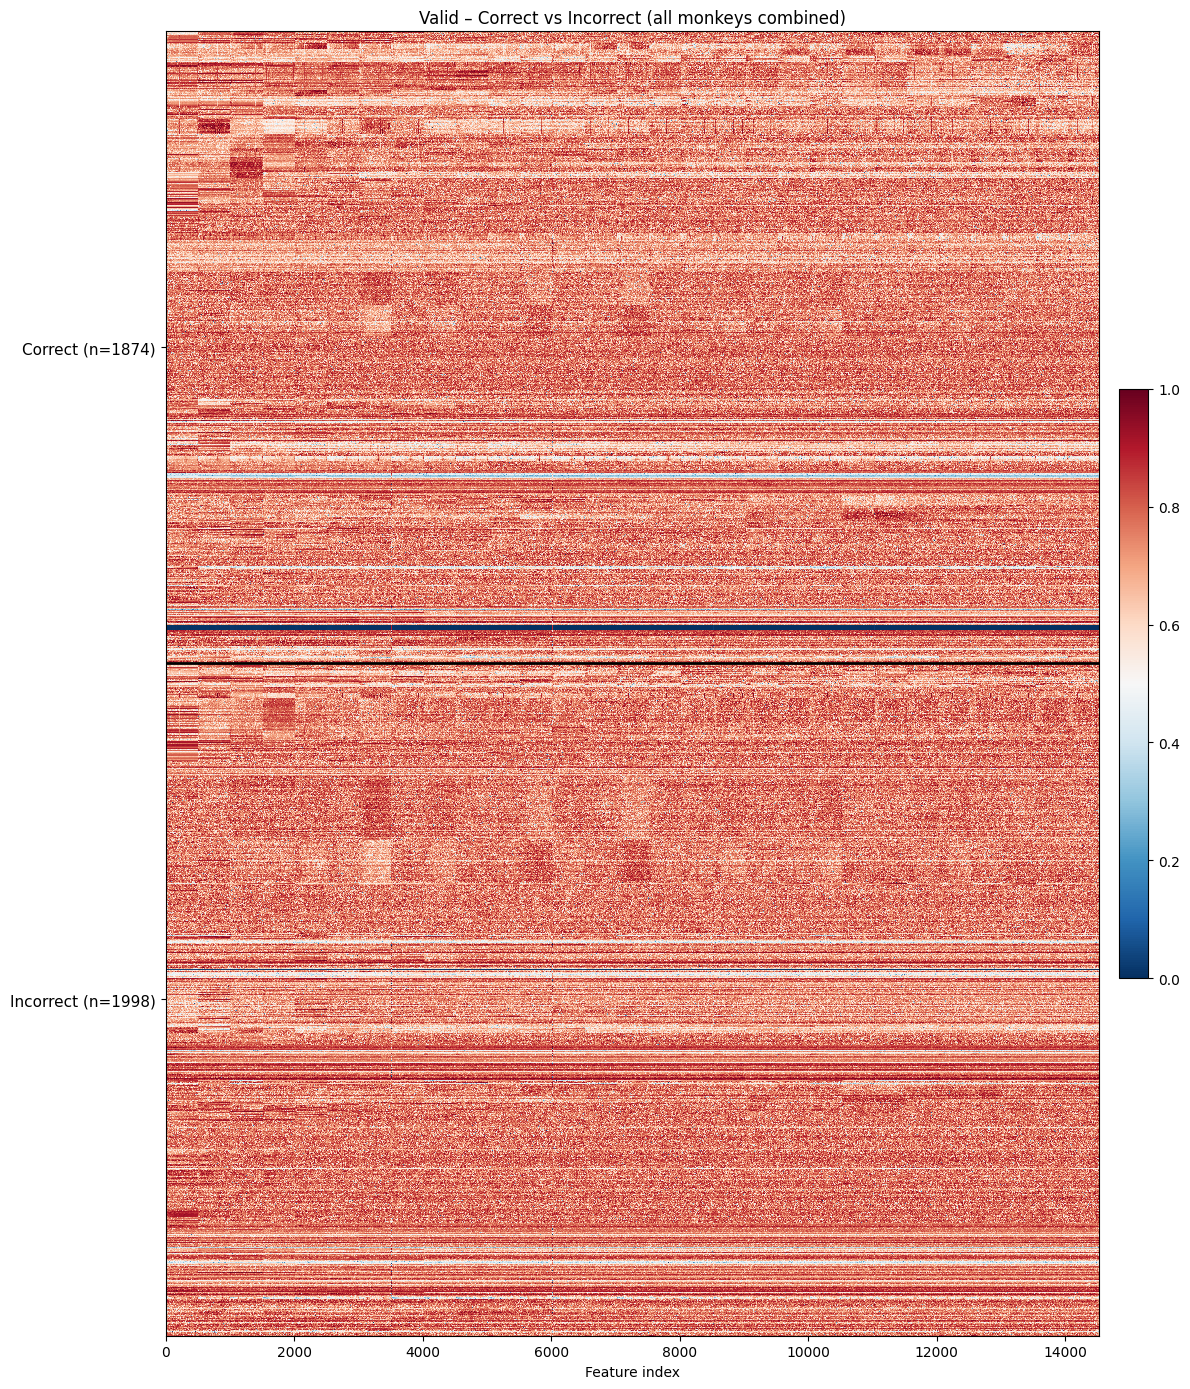

In [ ]:
X = X_all_valid
correct_mask   = (y_all_valid == y_all_pred)
order          = np.argsort(correct_mask, kind="stable")[::-1]
X_sorted       = X[order]
correct_sorted = correct_mask[order]

print(f"Feature matrix shape: {X.shape}")
fig, ax = plt.subplots(1, 1, figsize=(12, 14))
X_norm = (X - X.min(axis=1, keepdims=True)) / (X.max(axis=1, keepdims=True) - X.min(axis=1, keepdims=True) + 1e-8)
X_sorted_norm = X_norm[order]
im = ax.imshow(
    X_sorted_norm,
    aspect="auto",
    interpolation="none",
    cmap="RdBu_r",
    vmin=0,
    vmax=1,
)
split_point = int(np.sum(correct_sorted))
ax.axhline(split_point - 0.5, color="black", linewidth=2)
ax.set_xlabel("Feature index")
ax.set_yticks([
    split_point / 2,
    split_point + (len(X_sorted) - split_point) / 2
])
ax.set_yticklabels(
    [f"Correct (n={split_point})", f"Incorrect (n={len(X_sorted) - split_point})"],
    fontsize=11
)
ax.set_title("Valid – Correct vs Incorrect (all monkeys combined)")
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
plt.tight_layout()
plt.show()